<div style="display: flex; background-color: RGB(31,42,68);">
<h1 style="margin: auto; padding: 30px; color: white;">ANALYSE DES VENTES DE LA LIBRAIRIE LAPAGE</h1>
</div>

# Analyse pour Annabelle (Marketing)

Analyses demandées :

- l’évolution du <span style="color:#C2188B; font-weight:bold;">chiffre d’affaires</span>  
- la répartition par <span style="color:#C2188B; font-weight:bold;">catégorie</span>  
- le volume de <span style="color:#C2188B; font-weight:bold;">clients actifs</span>  
- le nombre de <span style="color:#C2188B; font-weight:bold;"> transactions</span> sur les 24 mois d’activité

<div style="background-color: #F4F6F7;" >
<h2 style="margin: auto; padding: 20px; color:#263E50; ">PHASE II : ANALYSES DES INDICATEURS DE VENTE</h2>
</div>

## 🎯 Objectif de ces analyses

À travers ces indicateurs, nous cherchons à comprendre la dynamique globale de l’activité commerciale de la librairie.

Question centrale : 
👉 La performance commerciale est-elle portée par plus de clients, plus d’achats, une hausse des prix, ou une concentration sur certains segments ?

-  📈 L’évolution du chiffre d’affaires permet d’évaluer la performance dans le temps : croissance, stagnation ou recul, ainsi que d’identifier d’éventuelles tendances ou saisonnalités.

- 🏷 La répartition par catégorie vise à identifier les segments de produits les plus contributifs au chiffre d’affaires et à détecter une éventuelle dépendance à certaines catégories.

- 👥 Le volume de clients actifs permet d’analyser la dynamique de la base client : acquisition, fidélisation et engagement.

- 🧾 Le nombre de transactions permet d’évaluer l’intensité d’achat et de distinguer une croissance liée au volume d’achats d’une croissance liée à l’augmentation du panier moyen.

---

<div style="background-color: #2E5EAA; border: 1px solid #2E5EAA;" >
<h3 style="margin: auto; padding: 20px; color: #F4F6F7; ">Importation des bibliothèques et chargement du fichier transactions-enrichies.csv de l'étape exploratoire</h3>
</div>


In [1]:
# Import des bibliothèques
import pandas as pd # pour la manipulation de données
import numpy as np # pour les calculs numériques
import matplotlib.pyplot as plt # pour la visualisation
import seaborn as sns # pour la visualisation avancée
from datetime import date # pour la manipulation de dates
from matplotlib.ticker import FuncFormatter # pour formater les axes des graphiques

# Configuration de l'affichage
pd.set_option('display.max_columns', None)  # Afficher toutes les colonnes
pd.set_option('display.max_rows', 100)      # Limiter à 100 lignes
pd.set_option('display.width', None)        # Pas de limite de largeur

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid') # Style de base pour les graphiques
plt.rcParams['figure.figsize'] = (12, 6) # Taille par défaut des figures
plt.rcParams['font.size'] = 12 # Taille de police par défaut

sns.set_theme(style="whitegrid") # Thème de Seaborn pour les graphiques

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F4F6F7",
    "axes.edgecolor": "#1F2A44",
    "axes.labelcolor": "#2C3E50",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.titlecolor": "#1F2A44",
    "xtick.color": "#2C3E50",
    "ytick.color": "#2C3E50",
    "grid.color": "#D5D8DC",
    "font.size": 11
})

sns.set_palette([
    "#2E5EAA",   # bleu principal
    "#C2188B",   # accent
    "#2E8B57",   # validation
    "#7F8C8D",   # neutre
    "#E67E22",   # avertissement
])
print("✅ Bibliothèques chargées avec succès !")
import os

# Dossier data/ au même niveau que le notebook
DATA_PATH = os.path.join(os.getcwd(), "../../data/processed")

transactions = pd.read_csv(os.path.join(DATA_PATH, "2-transactions_enrichies.csv"), sep=",", low_memory=False)

print("transactions :", transactions.shape)
transactions.head(5)

✅ Bibliothèques chargées avec succès !
transactions : (687534, 15)


,id_prod,date,session_id,client_id,price,categ,sex,birth,statut_actif,ca_total,segment_client,age,mois,annee,categ_label
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,Actif,1132.94,BtoC,54,2021-03,2021,Catégorie 0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,Actif,2314.74,BtoC,61,2021-03,2021,Catégorie 0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,Actif,4331.69,BtoC,33,2021-03,2021,Catégorie 0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,Actif,3022.26,BtoC,32,2021-03,2021,Catégorie 0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,Actif,1285.06,BtoC,65,2021-03,2021,Catégorie 0


<div style="background-color: #2E5EAA; border: 1px solid #2E5EAA;" >
<h3 style="margin: auto; padding: 20px; color: #F4F6F7; ">Prérequis : Faire les analyses sur les clients BtoC</h3>
</div>


Clients totaux : 8600
Clients BtoC : 8596
Transactions totales : 687534
Transactions BtoC : 640734


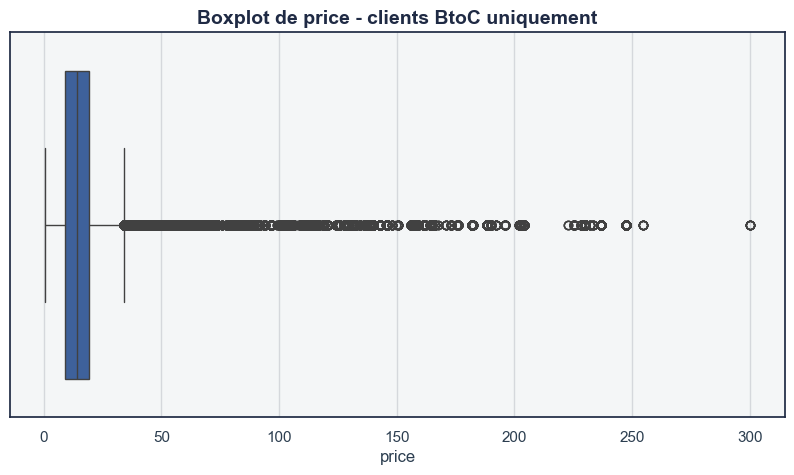

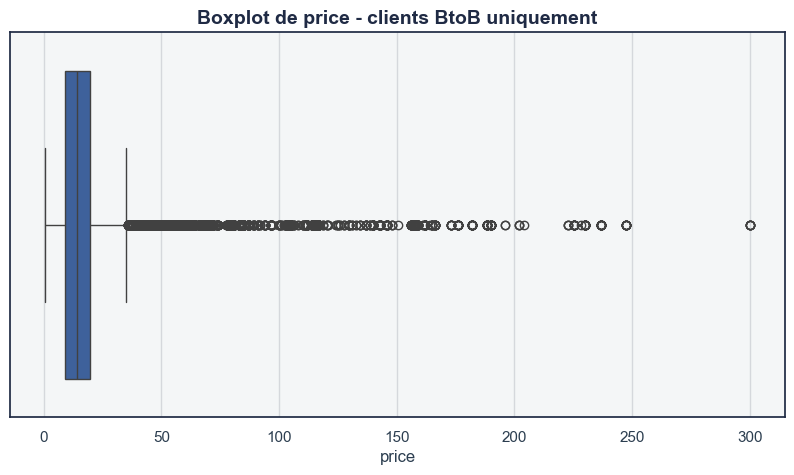

Clients BtoB : 4
Transactions BtoB : 46800


In [2]:
# Filtrer les transactions pour ne garder que les clients BtoC
seuil_btob = 100000  # au-dessus: BtoB, sinon: BtoC

# CA total par client
ca_client = transactions.groupby('client_id', as_index=False)['price'].sum().rename(columns={'price': 'ca_total'})

# Liste des clients BtoC
clients_btoc = ca_client.loc[ca_client['ca_total'] <= seuil_btob, 'client_id']
clients_btob = ca_client.loc[ca_client['ca_total'] > seuil_btob, 'client_id']

# Dataset transactions BtoC uniquement
transactions_btoc = transactions[transactions['client_id'].isin(clients_btoc)].copy()
transactions_btob = transactions[transactions['client_id'].isin(clients_btob)].copy()

print(f"Clients totaux : {ca_client['client_id'].nunique()}")
print(f"Clients BtoC : {clients_btoc.nunique()}")

print(f"Transactions totales : {len(transactions)}")
print(f"Transactions BtoC : {len(transactions_btoc)}")


# Optionnel : boxplot uniquement sur les BtoC
plt.figure(figsize=(10, 5))
sns.boxplot(x=transactions_btoc['price'])
plt.title('Boxplot de price - clients BtoC uniquement')
plt.show()

# Optionnel : boxplot uniquement sur les BtoB
plt.figure(figsize=(10, 5))
sns.boxplot(x=transactions_btob['price'])
plt.title('Boxplot de price - clients BtoB uniquement')
plt.show()
print(f"Clients BtoB : {clients_btob.nunique()}")
print(f"Transactions BtoB : {len(transactions_btob)}")

<a id="RNCP37837BC03"></a>

# 1- 📈  Structure du CA Annuel et Evolution du chiffre d'affaires mensuel

<div style="font-size: 12px; color: #666; margin-top: 10px;">
<strong>Bloc compétence :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">RNCP37837BC03</span> - Visualiser des données et interpréter des résultats
</div>

## 1.1 🏷 Structure du CA annuel par catégorie (barres 2021-2023)

D'ou vient le chiffre d'affaires ?

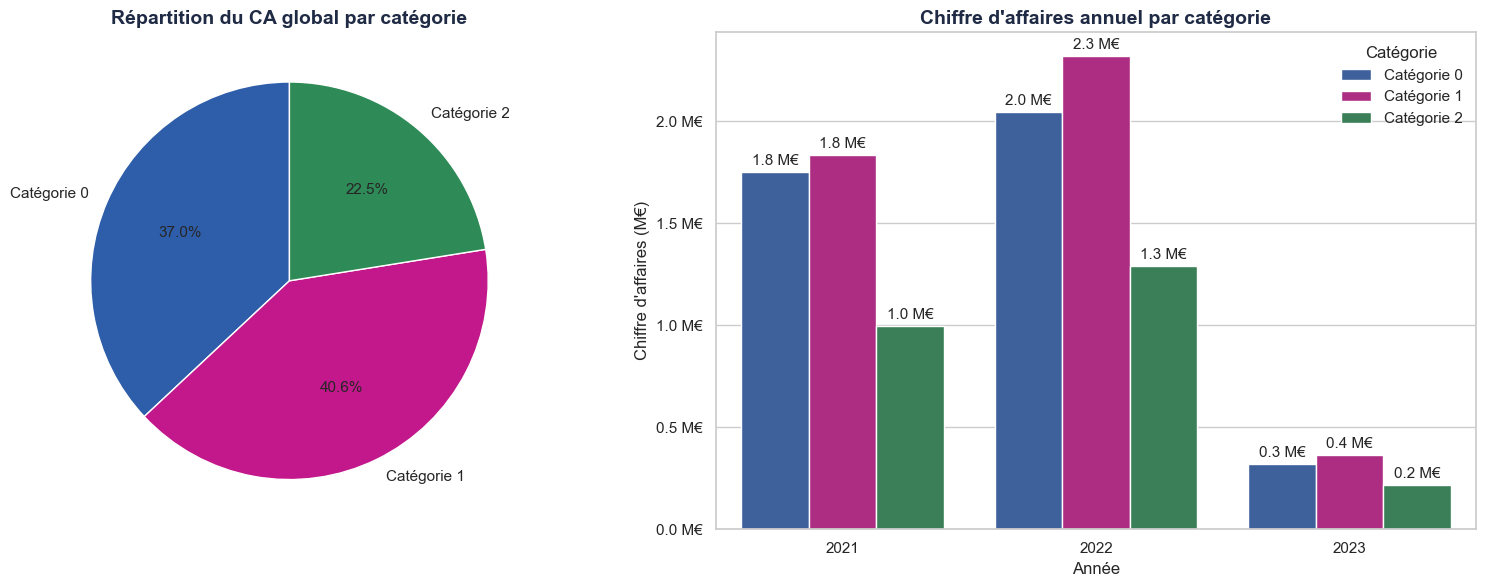

In [3]:
#Calcul du chiffre d'affaires par an et par catégorie de produits
ca_annuel_categ = transactions_btoc.groupby(['annee', 'categ_label'])['price'].sum().reset_index()
ca_annuel_categ.columns = ['annee', 'categ_label', 'ca']
ca_categ = transactions_btoc.groupby('categ_label')['price'].sum()

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Sous-graphe 1 : camembert du CA global par catégorie
axes[0].pie(ca_categ, labels=ca_categ.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title("Répartition du CA global par catégorie")

#Sous-graphe 2 : CA annuel par catégorie
sns.barplot(data=ca_annuel_categ, x='annee', y='ca', hue='categ_label', ax=axes[1])
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f} M€'))

for container in axes[1].containers:
        axes[1].bar_label( container,labels=[f'{v.get_height()/1e6:.1f} M€' for v in container], padding=3 )

axes[1].set_title("Chiffre d'affaires annuel par catégorie")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Chiffre d'affaires (M€)")
axes[1].legend(title='Catégorie')

plt.tight_layout()
plt.show()



Conclusion : 
- <span style="color:#C2188B; font-weight:bold;">Catégorie 1 ≈ 40 %</span>
- Catégorie 0 ≈ 37 %
- Catégorie 2 ≈ 23 %
- 👉 Cela nous renseigne sur la dépendance structurelle :

Le CA est principalement porté par les catégories 1 et 0.
La catégorie 2 est secondaire mais non négligeable.

On observe sur le graphique (barres 2021-2023) <span style="color:#C2188B; font-weight:bold;">une évolution similaire pour les 3 catégories </span>:

- 2021 → 2022 : hausse généralisée
- 2023 : forte baisse sur toutes les catégories
- 👉 Cette visualisation nous renseigne sur :
✅ Une croissance en 2022
⚠ Une chute en 2023
✅ Une cohérence entre catégories (elles évoluent dans le même sens)

Donc on identifie une <span style="color:#C2188B; font-weight:bold;">tendance globale</span>, mais ⚠ On ne sait pas si <span style="color:#C2188B; font-weight:bold;">2023 est</span> :
- une vraie crise ?
- une saisonnalité ?
- une année incomplète ?
- un effet ponctuel ?

#### Un agrégat annuel :
- masque <span style="color:#C2188B; font-weight:bold;">la saisonnalité</span>
- masque <span style="color:#C2188B; font-weight:bold;">les ruptures</span>
- masque <span style="color:#C2188B; font-weight:bold;">les pics</span>
- masque <span style="color:#C2188B; font-weight:bold;">les effets marketing</span>
- C'est pourquoi il est essentiel de compléter cette analyse par une étude mensuelle du CA pour comprendre les dynamiques sous-jacentes.

## 📈 1.2 Evolution du CA  mensuel

### 1.2.1 📈  Méthode de décomposition de la série temporelle par les moyennes mobiles  calculé sur le chiffre d'affaires journalier pour rechercher la granularité optimale d'analyse (7j, 30j, 60j) et identifier les tendances sous-jacentes. 

In [4]:
# Formatage du champ date en datetime et extraction de l'année
transactions_btoc['date'] = pd.to_datetime(transactions_btoc['date'])

# Calcul du CA Journalier
CA_journalier = transactions_btoc.groupby(pd.Grouper(key='date', freq='D'))['price'].sum().reset_index()

In [5]:
#calcul des moyennes mobiles sur 7 jours
CA_journalier['CA_MA7'] = CA_journalier['price'].rolling(window=7).mean()

#calcul des moyennes mobiles sur 30 jours
CA_journalier['CA_MA30'] = CA_journalier['price'].rolling(window=30).mean()

#calcul des moyennes mobiles sur 60 jours
CA_journalier['CA_MA60'] = CA_journalier['price'].rolling(window=60).mean()



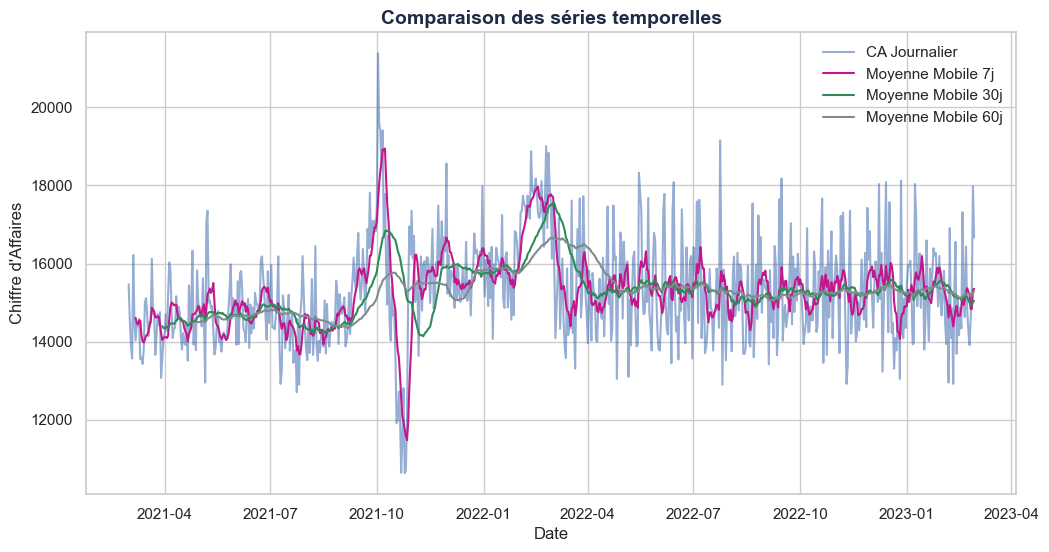

In [6]:
#Comparer les séries temporelles pour visualiser les tendances saisonnières
fig3 =plt.figure(figsize=(12,6))
plt.plot(CA_journalier['date'], CA_journalier['price'], label='CA Journalier', alpha=0.5)
plt.plot(CA_journalier['date'], CA_journalier['CA_MA7'], label='Moyenne Mobile 7j')
plt.plot(CA_journalier['date'], CA_journalier['CA_MA30'], label='Moyenne Mobile 30j')
plt.plot(CA_journalier['date'], CA_journalier['CA_MA60'], label='Moyenne Mobile 60j')
plt.xlabel('Date')
plt.ylabel('Chiffre d\'Affaires')
plt.title('Comparaison des séries temporelles')
plt.legend()
plt.show()

### Interprétation du graphique on observe 3 courbes : 
- 1️⃣ <span style="color:#C2188B; font-weight:bold;">Forte volatilité du CA journalier</span>
La courbe journalière (bleu) est très fluctuante.
On observe des pics importants (jusqu’à ~20–21k) et des creux marqués (~11–12k).
Cette variabilité masque la tendance de fond, d’où l’intérêt des moyennes mobiles.

- 2️⃣ Moyenne mobile 7 jours (court terme)
Elle réagit rapidement aux variations.
On voit clairement :
Un pic important vers octobre 2021, suivi d’un fort décrochage.
Un nouveau pic début 2022.
Elle <span style="color:#C2188B; font-weight:bold;">met en évidence les chocs ponctuels (probablement événements commerciaux, saisonnalité, promotions, etc.).</span>
👉 Elle capte bien la dynamique court terme et les effets saisonniers courts.

- 3️⃣ <span style="color:#C2188B; font-weight:bold;">Moyenne mobile 30 jours (tendance de fond)</span>
Beaucoup plus lissée.
Elle montre :
✅ Une hausse progressive mi-2021 → fin 2021
✅ Un point haut début 2022
⬇️ Puis un léger repli
➖ Ensuite une stabilisation autour de 16,3k–16,6k
👉<span style="color:#C2188B; font-weight:bold;"> Depuis mi-2022, la tendance semble globalement stable, </span>sans croissance marquée ni décroissance forte.

📊 Ce que la granularité du CA mensuel permet de montrer:
- ✅ Détecter une saisonnalité (rentrée scolaire ? Noël ?)
- ✅ Identifier un point de rupture
- ✅ Voir si la baisse 2023 est progressive ou brutale
- ✅ Analyser l’impact d’événements spécifiques
- ✅ Vérifier si l’année 2023 est complète


In [7]:
# Granularité du CA mensuel choisie pour l'analyse de la saisonnalité :
transactions_btoc ['mois_dt'] = transactions_btoc['date'].dt.to_period('M').dt.to_timestamp()
ca_mensuel = transactions_btoc.groupby('mois_dt')['price'].sum().reset_index()
ca_mensuel.columns = ['mois_dt','ca']
ca_mensuel.head(3)


,mois_dt,ca
0,2021-03-01,445918.71
1,2021-04-01,439337.85
2,2021-05-01,454887.46


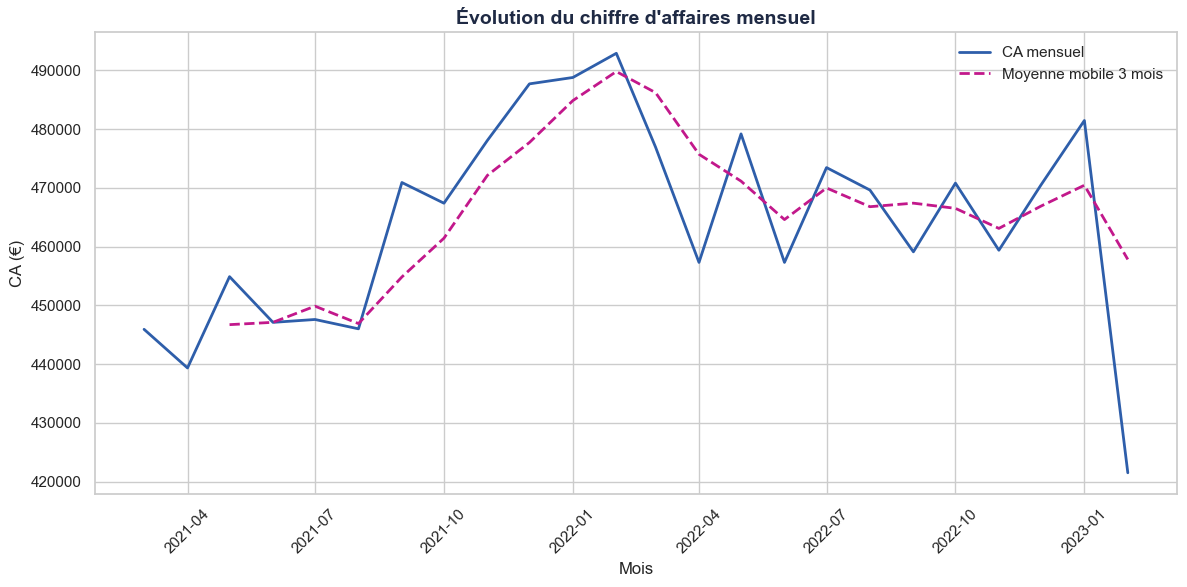

In [8]:
# Moyenne mobile 3 mois
ca_mensuel['mm3'] = ca_mensuel['ca'].rolling(window=3).mean()

# Graphique
fig2, ax = plt.subplots()
ax.plot(ca_mensuel['mois_dt'], ca_mensuel['ca'],  linewidth=2, label='CA mensuel')
ax.plot(ca_mensuel['mois_dt'], ca_mensuel['mm3'], linewidth=2, linestyle='--', label='Moyenne mobile 3 mois')
ax.set_title("Évolution du chiffre d'affaires mensuel", fontsize=14)
ax.set_xlabel("Mois")
ax.set_ylabel("CA (€)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


4️⃣ Lecture globale
On peut découper l’évolution en 3 phases :
- 📈 Phase 1 – Croissance (mi-2021 → début 2022)
Tendance haussière claire.
Dynamique positive.

- ⚠️ Phase 2 – Correction / normalisation (début 2022)
Repli après un pic important.
Retour vers un niveau plus stable.

- ➖ Phase 3 – Plateau (mi-2022 → début 2023)
CA stabilisé.
Croissance faible voire nulle.
Volatilité journalière toujours forte mais sans tendance claire.

 Conclusion business :
- ✅ L’activité semble résiliente (pas de tendance baissière structurelle).
- ⚠️ Mais il n’y a pas de dynamique de croissance récente.
- La moyenne 30J indique un <span style="color:#C2188B; font-weight:bold;">palier.</span>
- La moyenne 7J montre <span style="color:#C2188B; font-weight:bold;">des à-coups mais pas d’accélération durable.</span>

### 1.2.2 📈  Décomposition de la série temporelle grâce au modèle "seasonal_decompose" (STL) en 3 composantes : tendance, saisonnalité et résidus

La moyenne mobile permet une lecture simplifiée de la dynamique, mais <span style="color:#C2188B; font-weight:bold;">elle ne distingue pas les composantes structurelles et saisonnières.</span> La décomposition de la série temporelle permet d’isoler ces effets afin d’identifier si le plateau observé relève d’un ralentissement réel ou d’un cycle naturel.

⚠️ Important méthodologique : Pour utiliser seasonal_decompose correctement :

- Données régulières (mensuelles ici ✅)
- Pas trop de valeurs manquantes
- Au moins 2 cycles complets (donc ≥ 24 mois pour saisonnalité annuelle)

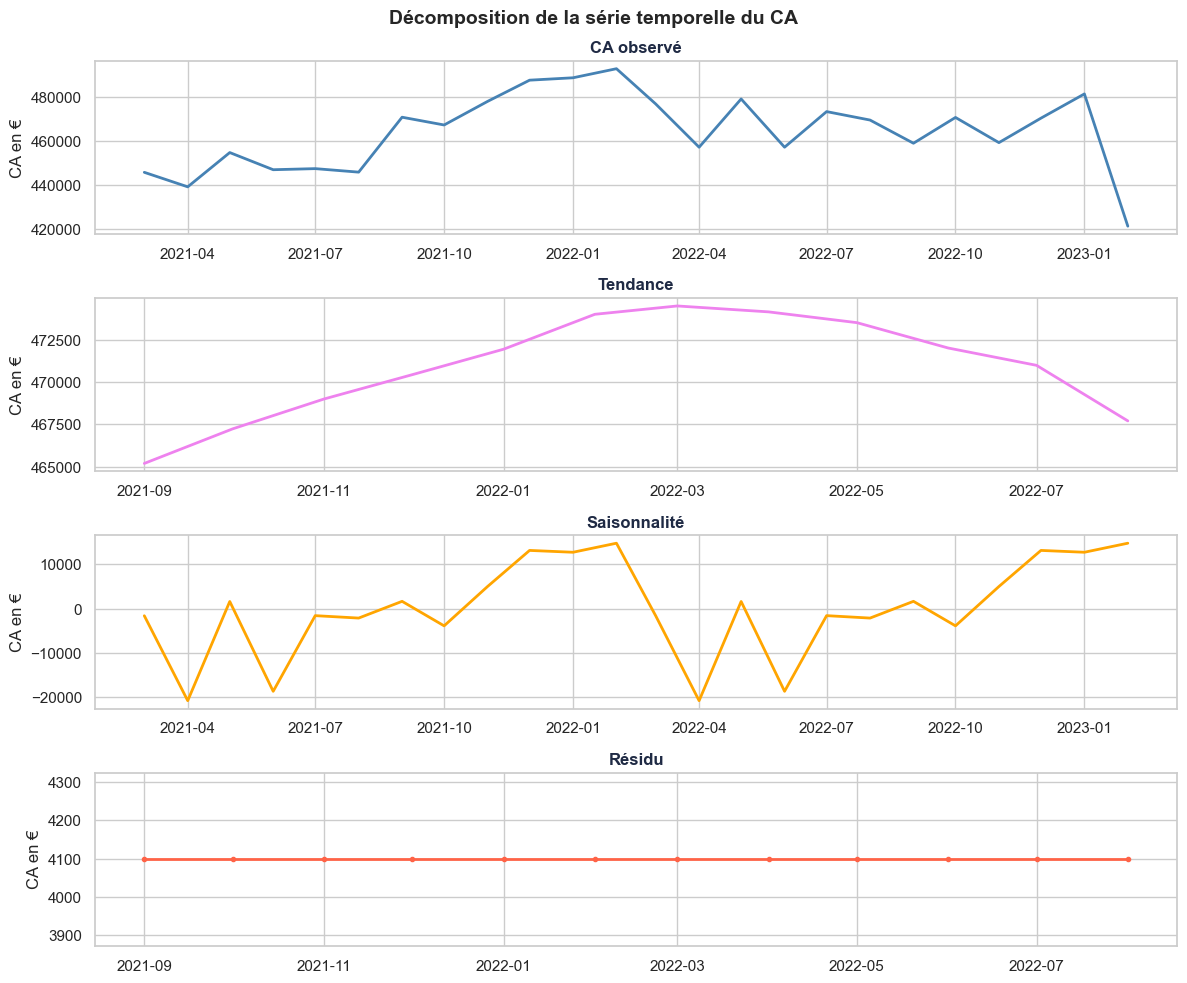

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates # pour formater les dates sur les graphiques


#Série temporelle du CA mensuel avec un index temporel _ datetime
ca_ts = ca_mensuel.set_index('mois_dt')['ca']

# Décomposition de la série temporelle
decomposition = seasonal_decompose(ca_ts, model='additive', period=12)

tendance = decomposition.trend
saisonnalite = decomposition.seasonal
residus = decomposition.resid


# Graphique
fig4, axes = plt.subplots(4, 1, figsize=(12, 10))
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[0].plot(decomposition.observed, color='steelblue', linewidth=2)
axes[0].set_title('CA observé', fontsize=12)
axes[0].set_ylabel('CA en €')


axes[1].plot(decomposition.trend, color='violet', linewidth=2)
axes[1].set_title('Tendance', fontsize=12)
axes[1].set_ylabel('CA en €')


axes[2].plot(decomposition.seasonal, color='orange', linewidth=2)
axes[2].set_title('Saisonnalité', fontsize=12)
axes[2].set_ylabel('CA en €')


axes[3].plot(decomposition.resid, color='tomato', linewidth=2, marker='o', markersize=3)
axes[3].set_title('Résidu', fontsize=12)
axes[3].set_ylabel('CA en €')

plt.suptitle("Décomposition de la série temporelle du CA", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interprétation de la décomposition : 
- La tendance montre une croissance régulière du chiffre d'affaires de septembre 2021 à mars 2022, avec une légère accélération à partir de mi-février, ce qui peut indiquer une augmentation de la clientèle ou une meilleure fidélisation puis une légère descente, la croissance se stabilise ensuite.
- <span style="color:#C2188B; font-weight:bold;">La saisonnalité révèle des pics de ventes récurrents en mai, septembre, décembre, probablement liés aux fêtes de fin d'année et un pic en février 2022 et des creux en janvier , ce qui est typique pour de nombreux commerces.</span>
- Les résidus ne montrent pas de fluctuations aléatoires autour de la tendance et de la saisonnalité, ce qui suggère <span style="color:#C2188B; font-weight:bold;">un modèle d'affaires stable et prévisible </span> sans évènements exceptionnels ou perturbateurs.


| Période | Intensité | Nature |
|----------|-----------|---------|
| Rentrée littéraire (fin août-septembre) | 🔥🔥🔥 | Pic structurel |
| Prix littéraires (oct-nov) | 🔥🔥 | Pic court |
| Noël (décembre) | 🔥🔥🔥 | Pic annuel majeur |
| Événements auteurs | 🔥 | Pics ponctuels |


# 2-🏷 Evolution du Chiffre d'affaires mensuel par catégorie de produits 

- 🏷 La répartition par catégorie vise à identifier les segments de produits les plus contributifs au chiffre d’affaires et à détecter une éventuelle dépendance à certaines catégories.
- ici, on cherche à identifier quels segments pilotent réellement la dynamique mensuelle du chiffre d’affaires et à comprendre si la croissance (ou le plateau) observé globalement est homogène ou porté par une catégorie spécifique.
- Business insight : Certaines catégories compensent les baisses des autres ? Ou au contraire :  sont-elles corrélées et donc risquées en cas de choc global?

L’analyse mensuelle révèle que la <span style="color:#C2188B; font-weight:bold;">croissance repose essentiellement sur la Catégorie 1, tandis que la Catégorie 0 assure la stabilité et que la Catégorie 2 est plus volatile.</span> La stratégie doit donc différencier investissement, sécurisation et optimisation selon les segments.

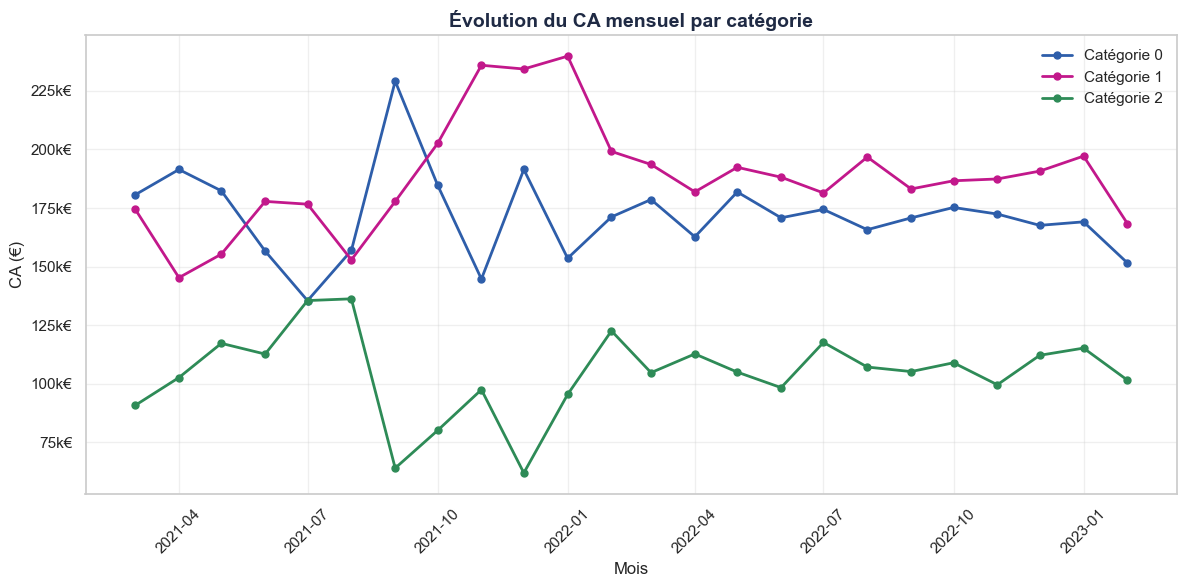

In [12]:
import matplotlib.ticker as mticker # pour formater les axes des graphiques en k€
import matplotlib.dates as mdates # pour formater les dates sur les graphiques

# Conversion du champ date en datetime et extraction du mois
transactions_btoc['mois'] = transactions_btoc['date'].dt.to_period('M')

# CA mensuel par catégorie
ca_mensuel_categ = transactions_btoc.groupby(['mois', 'categ_label'])['price'].sum().reset_index()
ca_mensuel_categ['mois_dt'] = ca_mensuel_categ['mois'].dt.to_timestamp()

# Visualisation CA  par catégorie
fig6, ax = plt.subplots(figsize=(12, 6))

for categ, group in ca_mensuel_categ.groupby('categ_label'):
    ax.plot(group['mois_dt'], group['price'],
            marker='o', markersize=5, linewidth=2,
            label=categ)

# Format axe Y en k€
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k€'))

ax.set_title("Évolution du CA mensuel par catégorie", fontsize=14, fontweight='bold')
ax.set_xlabel("Mois")
ax.set_ylabel("CA (€)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



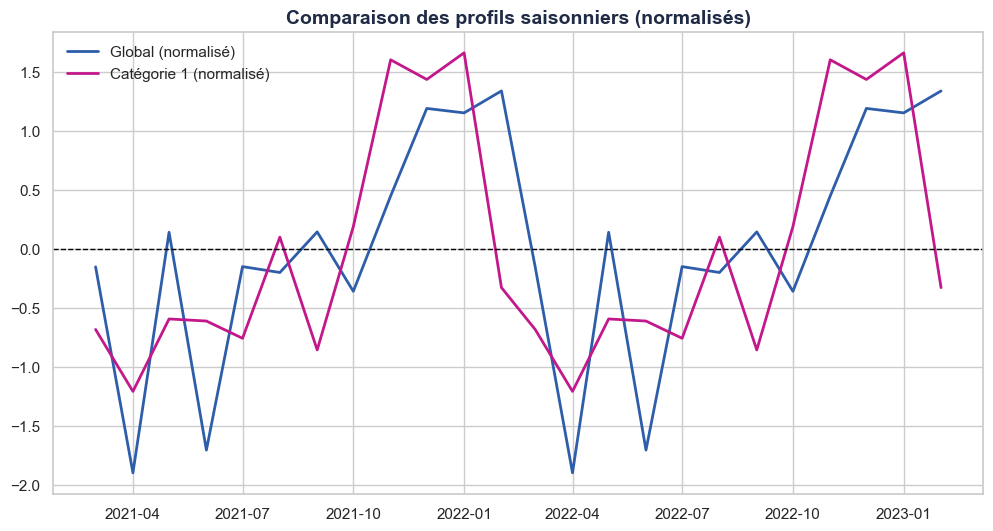

np.float64(0.6226008889210696)

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
import matplotlib.dates as mdates

from statsmodels.tsa.seasonal import seasonal_decompose

# CA global mensuel
ca_global = transactions_btoc.groupby('mois_dt')['price'].sum()

# CA catégorie 1 mensuel
ca_cat1 = transactions_btoc[transactions_btoc['categ'] == 1] \
    .groupby('mois_dt')['price'].sum()

decomp_global = seasonal_decompose(ca_global, model='additive', period=12)
decomp_cat1 = seasonal_decompose(ca_cat1, model='additive', period=12)

plt.figure(figsize=(12,6))

plt.plot(decomp_global.seasonal / decomp_global.seasonal.std(),
         label='Global (normalisé)', linewidth=2)

plt.plot(decomp_cat1.seasonal / decomp_cat1.seasonal.std(),
         label='Catégorie 1 (normalisé)', linewidth=2)

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title("Comparaison des profils saisonniers (normalisés)")
plt.legend()
plt.show()

decomp_global.seasonal.corr(decomp_cat1.seasonal)


On observe que ✅ Les pics de fin d’année sont alignés
❌ Mais certains creux ne coïncident pas
❌ Certaines amplitudes sont décalées

Donc :

- Même cycle général
- Mais dynamique interne différente
- <span style="color:#C2188B; font-weight:bold;">La corrélation positive mais modérée indique que la catégorie 1 participe à la saisonnalité globale sans en être l’unique moteur.</span> La dynamique du chiffre d’affaires repose donc sur une contribution multi-segment.

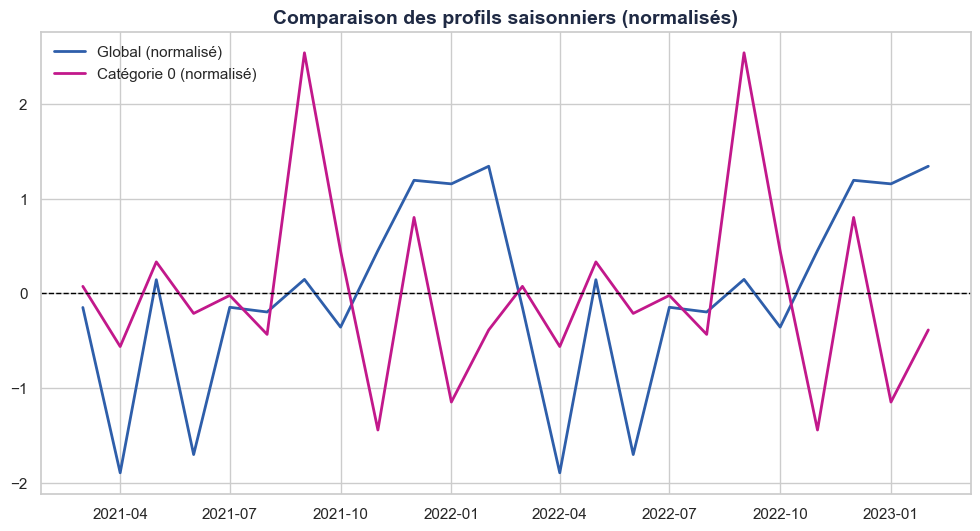

np.float64(0.019484298999149458)

In [14]:
# CA catégorie 0 mensuel
ca_cat0 = transactions_btoc[transactions_btoc['categ'] == 0] \
    .groupby('mois_dt')['price'].sum()

decomp_global = seasonal_decompose(ca_global, model='additive', period=12)
decomp_cat0 = seasonal_decompose(ca_cat0, model='additive', period=12)

plt.figure(figsize=(12,6))

plt.plot(decomp_global.seasonal / decomp_global.seasonal.std(),
         label='Global (normalisé)', linewidth=2)

plt.plot(decomp_cat0.seasonal / decomp_cat0.seasonal.std(),
         label='Catégorie 0 (normalisé)', linewidth=2)

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title("Comparaison des profils saisonniers (normalisés)")
plt.legend()
plt.show()

decomp_global.seasonal.corr(decomp_cat0.seasonal)

Contrairement à la catégorie 1, la catégorie 0 présente un profil saisonnier peu corrélé à celui du chiffre d’affaires global. Elle ne constitue donc pas un moteur saisonnier, mais plutôt un socle de revenus plus indépendant des cycles annuels.

In [ ]:
# CA catégorie 2 mensuel
ca_cat2 = transactions_btoc[transactions_btoc['categ'] == 2] \
    .groupby('mois_dt')['price'].sum()

decomp_global = seasonal_decompose(ca_global, model='additive', period=12)
decomp_cat2 = seasonal_decompose(ca_cat2, model='additive', period=12)

plt.figure(figsize=(12,6))

plt.plot(decomp_global.seasonal / decomp_global.seasonal.std(),
         label='Global (normalisé)', linewidth=2)

plt.plot(decomp_cat2.seasonal / decomp_cat2.seasonal.std(),
         label='Catégorie 2 (normalisé)', linewidth=2)

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title("Comparaison des profils saisonniers (normalisés)")
plt.legend()
plt.show()

decomp_global.seasonal.corr(decomp_cat2.seasonal)

In [ ]:
# Tableau de synthèse : mois où la catégorie 2 sur/sous-performe le profil global
s_global = decomp_global.seasonal / decomp_global.seasonal.std()
s_cat2 = decomp_cat2.seasonal / decomp_cat2.seasonal.std()

comp = (
    s_global.rename('global_norm')
    .to_frame()
    .join(s_cat2.rename('cat2_norm'), how='inner')
    .dropna()
    .sort_index()
 )
comp['delta_cat2_vs_global'] = comp['cat2_norm'] - comp['global_norm']
comp['mois'] = comp.index.strftime('%Y-%m')

top5_opportunites = (
    comp.sort_values('delta_cat2_vs_global', ascending=False)
    [['mois', 'delta_cat2_vs_global', 'cat2_norm', 'global_norm']]
    .head(5)
    .reset_index(drop=True)
 )

top5_risques = (
    comp.sort_values('delta_cat2_vs_global', ascending=True)
    [['mois', 'delta_cat2_vs_global', 'cat2_norm', 'global_norm']]
    .head(5)
    .reset_index(drop=True)
 )

print('Top 5 mois opportunistes (Catégorie 2 > Global)')
display(top5_opportunites.style.format({
    'delta_cat2_vs_global': '{:+.3f}',
    'cat2_norm': '{:+.3f}',
    'global_norm': '{:+.3f}'
}))

print('Top 5 mois à risque (Catégorie 2 < Global)')
display(top5_risques.style.format({
    'delta_cat2_vs_global': '{:+.3f}',
    'cat2_norm': '{:+.3f}',
    'global_norm': '{:+.3f}'
}))

print(f"Corrélation saisonnière Catégorie 2 vs Global : {comp['cat2_norm'].corr(comp['global_norm']):.3f}")

Contrairement à la catégorie 1, la catégorie 2 présente un profil saisonnier à l'inverse de celui du chiffre d’affaires global. <span style="color:#C2188B; font-weight:bold;">Si la corrélation est négative, la Catégorie 2 joue un rôle contra-cyclique.</span> 



📌 Implications stratégiques à ce stade : 
- 1️⃣ Prioriser l’investissement marketing sur la Catégorie 1
→ Maximiser le levier sur le segment le plus contributif.

- 2️⃣ Maintenir et fidéliser sur la Catégorie 0
→ Consolider la stabilité du chiffre d’affaires.

- 3️⃣ Optimiser la gestion de la Catégorie 2
→ Adapter les stocks et les campagnes promotionnelles à sa saisonnalité.

# 3- 👥 Volume de clients actifs 

Sur la courbe du nombre de clients actifs par mois, on observe les éléments suivants :

- ✅ <span style="color:#C2188B; font-weight:bold;">Pic très marqué vers octobre 2021</span>
- ✅ Stabilisation ensuite autour d’un plateau
- ✅ Quelques fluctuations mais pas de tendance haussière forte
- ✅ Baisse nette en fin de période





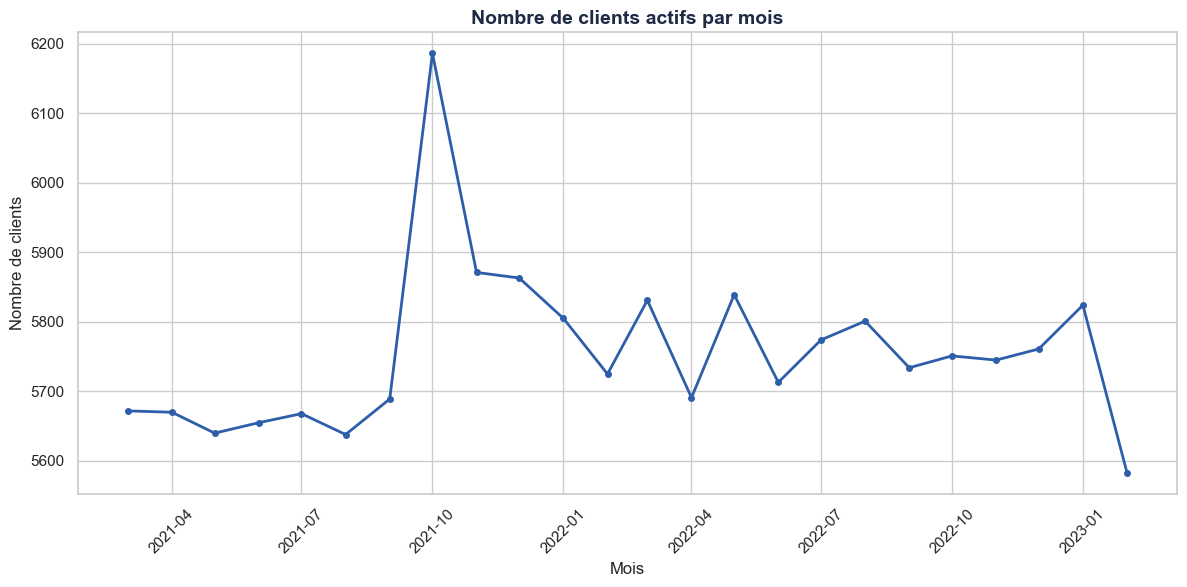

Nombre de mois comparés : 24
Corrélation Pearson (CA vs clients actifs) : 0.5689
Corrélation Spearman (CA vs clients actifs) : 0.7774


,mois_dt,ca,nb_clients
0,2021-03-01,445918.71,5672
1,2021-04-01,439337.85,5670
2,2021-05-01,454887.46,5640
3,2021-06-01,447102.17,5655
4,2021-07-01,447593.15,5668


In [15]:
# Nombre de clients distincts par mois
clients_mois = transactions_btoc.groupby('mois_dt')['client_id'].nunique().reset_index()
clients_mois.columns = ['mois_dt', 'nb_clients']

# Visualisation de l'évolution du nombre de clients actifs par mois
fig7, ax = plt.subplots()
ax.plot(clients_mois['mois_dt'], clients_mois['nb_clients'], linewidth=2, marker='o', markersize=4)
ax.set_title("Nombre de clients actifs par mois", fontsize=14)
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Corrélation : CA mensuel vs nombre de clients actifs mensuels (mêmes mois)
ca_mensuel_corr = transactions_btoc.groupby('mois_dt')['price'].sum().reset_index()
ca_mensuel_corr.columns = ['mois_dt', 'ca']

corr_df = ca_mensuel_corr.merge(clients_mois, on='mois_dt', how='inner').sort_values('mois_dt')

corr_pearson = corr_df['ca'].corr(corr_df['nb_clients'], method='pearson')
corr_spearman = corr_df['ca'].corr(corr_df['nb_clients'], method='spearman')

print(f"Nombre de mois comparés : {len(corr_df)}")
print(f"Corrélation Pearson (CA vs clients actifs) : {corr_pearson:.4f}")
print(f"Corrélation Spearman (CA vs clients actifs) : {corr_spearman:.4f}")
corr_df.head()

<a id="RNCP37837BC03-TREND"></a>

### 💡 Interprétation - Reporting des tendances

<div style="font-size: 12px; color: #666; margin-top: 10px;">
<strong>Compétence :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Reporting des tendances</span> - Analyser les tendances pour orienter les décisions stratégiques
</div>

# 4- 📦 Nombre de produits achetés par mois

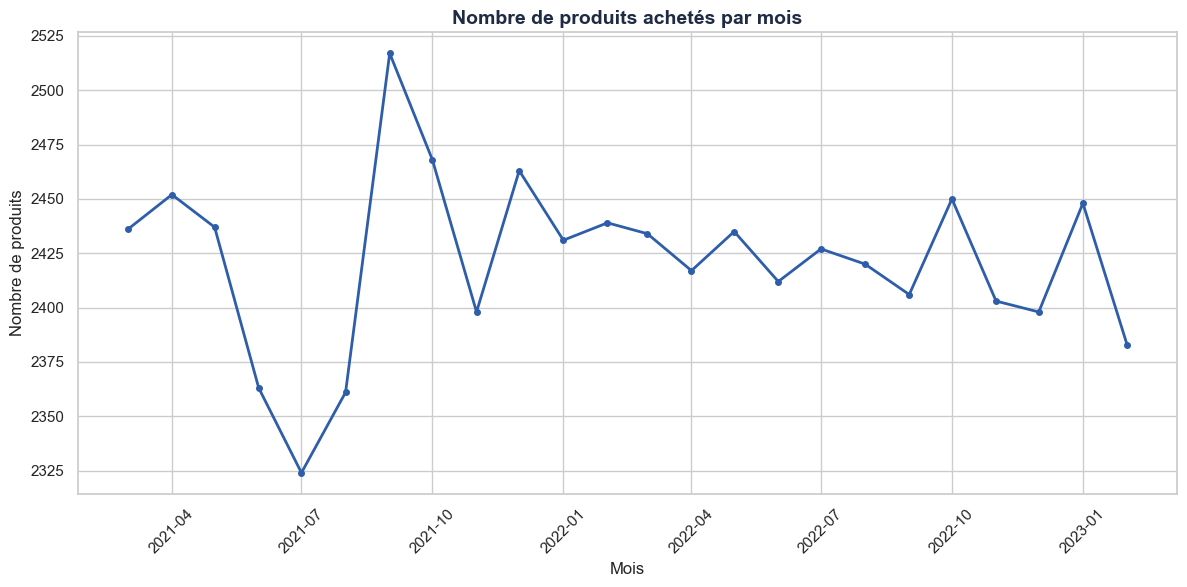

Nombre de mois comparés : 24
Corrélation Pearson (CA vs nombre de produits) : 0.4707
Corrélation Spearman (CA vs nombre de produits) : 0.4049


,mois_dt,ca,nb_produits
0,2021-03-01,445918.71,2436
1,2021-04-01,439337.85,2452
2,2021-05-01,454887.46,2437
3,2021-06-01,447102.17,2363
4,2021-07-01,447593.15,2324


In [55]:
# Nombre de produits achetés par mois
produits_mois = transactions_btoc.groupby('mois_dt')['id_prod'].nunique().reset_index()
produits_mois.columns = ['mois_dt', 'nb_produits']

# Visualisation de l'évolution du nombre de produits achetés par mois
fig7, ax = plt.subplots()
ax.plot(produits_mois['mois_dt'], produits_mois['nb_produits'], linewidth=2, marker='o', markersize=4)
ax.set_title("Nombre de produits achetés par mois", fontsize=14)
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de produits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Corrélation : CA mensuel vs nombre de produits achetés mensuels (mêmes mois)
ca_mensuel_corr = transactions_btoc.groupby('mois_dt')['price'].sum().reset_index()
ca_mensuel_corr.columns = ['mois_dt', 'ca']

corr_df = ca_mensuel_corr.merge(produits_mois, on='mois_dt', how='inner').sort_values('mois_dt')

corr_pearson = corr_df['ca'].corr(corr_df['nb_produits'], method='pearson')
corr_spearman = corr_df['ca'].corr(corr_df['nb_produits'], method='spearman')

print(f"Nombre de mois comparés : {len(corr_df)}")
print(f"Corrélation Pearson (CA vs nombre de produits) : {corr_pearson:.4f}")
print(f"Corrélation Spearman (CA vs nombre de produits) : {corr_spearman:.4f}")
corr_df.head()

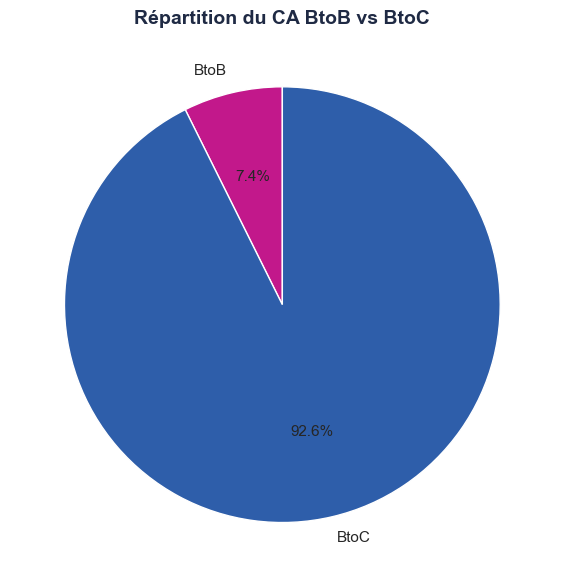

,segment_client,ca_total
0,BtoB,884296.09
1,BtoC,11143367.01


In [16]:
# Répartition du CA entre clients BtoB et BtoC (camembert)
seuil_btob = 100000

# 1) CA total par client (base complète)
ca_client_all = (
    transactions.groupby('segment_client', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'ca_total'})
)


# 4) Camembert
fig11, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    ca_client_all['ca_total'],
    labels=ca_client_all['segment_client'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#C2188B', '#2E5EAA']
 )
ax.set_title('Répartition du CA BtoB vs BtoC', fontsize=14)
plt.tight_layout()
plt.show()

# Tableau de contrôle
display(ca_client_all)


Statistiques CA par client :
count      8600.000000
mean       1398.565477
std        5202.771679
min           6.310000
25%         562.730000
50%        1045.695000
75%        1797.720000
max      326039.890000
Name: ca_total, dtype: float64


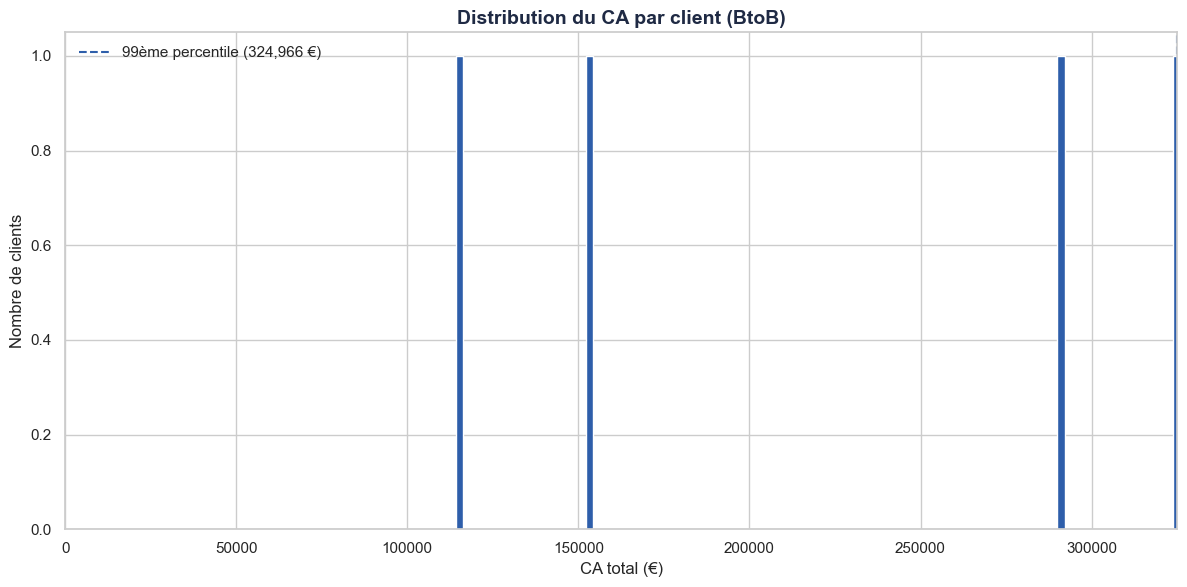


Top 10 clients par CA :
     client_id   ca_total
677     c_1609  326039.89
4388    c_4958  290227.03
6337    c_6714  153918.60
2724    c_3454  114110.57
634     c_1570    5285.82
2513    c_3263    5276.87
1268    c_2140    5260.18
2108    c_2899    5214.05
7006    c_7319    5155.77
7715    c_7959    5135.75


In [17]:
# CA total par client
ca_client = transactions.groupby('client_id')['price'].sum().reset_index()
ca_client.columns = ['client_id', 'ca_total']
ca_client = ca_client.sort_values('ca_total', ascending=False)

# Statistiques descriptives
print("Statistiques CA par client :")
print(ca_client['ca_total'].describe())

# Séparation BtoB / BtoC pour la visualisation
btob_viz = ca_client[ca_client['ca_total'] >= 100000]

# Limite axe X au 99ème percentile pour voir la vraie distribution
p99 = btob_viz['ca_total'].quantile(0.99)

fig, ax = plt.subplots()
ax.hist(btob_viz['ca_total'], bins=100,  edgecolor='white')
ax.set_xlim(0, p99)

# Annotation p99
ax.axvline(x=p99, linestyle='--', linewidth=1.5,
           label=f'99ème percentile ({p99:,.0f} €)')

ax.set_title("Distribution du CA par client (BtoB)", fontsize=14)
ax.set_xlabel("CA total (€)")
ax.set_ylabel("Nombre de clients")
ax.legend()
plt.tight_layout()
plt.show()

# Top 10 clients
print("\nTop 10 clients par CA :")
print(ca_client.head(10))

Statistiques CA par client :
count      8600.000000
mean       1398.565477
std        5202.771679
min           6.310000
25%         562.730000
50%        1045.695000
75%        1797.720000
max      326039.890000
Name: ca_total, dtype: float64


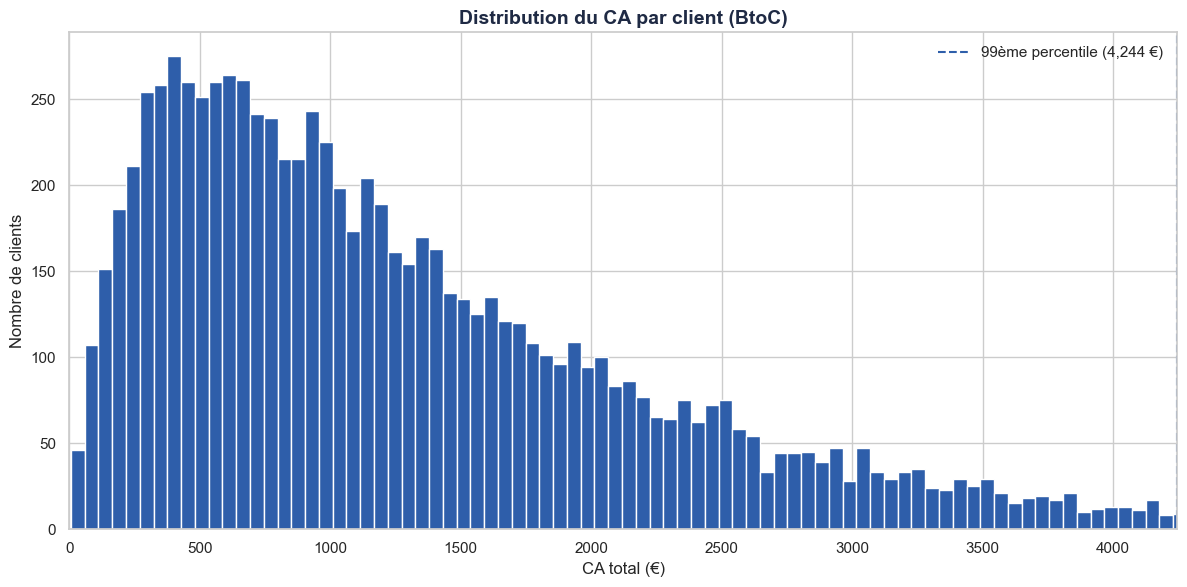


Top 10 clients par CA :
     client_id   ca_total
677     c_1609  326039.89
4388    c_4958  290227.03
6337    c_6714  153918.60
2724    c_3454  114110.57
634     c_1570    5285.82
2513    c_3263    5276.87
1268    c_2140    5260.18
2108    c_2899    5214.05
7006    c_7319    5155.77
7715    c_7959    5135.75


In [18]:
# CA total par client
ca_client = transactions.groupby('client_id')['price'].sum().reset_index()
ca_client.columns = ['client_id', 'ca_total']
ca_client = ca_client.sort_values('ca_total', ascending=False)

# Statistiques descriptives
print("Statistiques CA par client :")
print(ca_client['ca_total'].describe())

# Séparation BtoB / BtoC pour la visualisation
btoc_viz = ca_client[ca_client['ca_total'] <= 100000]

# Limite axe X au 99ème percentile pour voir la vraie distribution
p99 = btoc_viz['ca_total'].quantile(0.99)

fig, ax = plt.subplots()
ax.hist(btoc_viz['ca_total'], bins=100,  edgecolor='white')
ax.set_xlim(0, p99)

# Annotation p99
ax.axvline(x=p99, linestyle='--', linewidth=1.5,
           label=f'99ème percentile ({p99:,.0f} €)')

ax.set_title("Distribution du CA par client (BtoC)", fontsize=14)
ax.set_xlabel("CA total (€)")
ax.set_ylabel("Nombre de clients")
ax.legend()
plt.tight_layout()
plt.show()

# Top 10 clients
print("\nTop 10 clients par CA :")
print(ca_client.head(10))

<a id="RNCP37837BC03-NARRATION"></a>

### 🎬 Récit des résultats

<div style="font-size: 12px; color: #666; margin-top: 10px;">
<strong>Compétence :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Récit des résultats</span> - Utiliser des procédés narratifs pour dynamiser la présentation
</div>

# 5- 🧾 Nombre de transactions sur 24 mois d'activités

### Pourquoi analyser le nombre de transactions sur 24 mois ?

Cette section permet de mesurer l'intensite d'achat dans le temps et de verifier si l'evolution du chiffre d'affaires est surtout portee par :
- une augmentation du volume de transactions,
- une hausse du panier moyen,
- ou un mix des deux.

Sur une fenetre de 24 mois, on peut distinguer les phases de croissance, de stabilisation et de repli, tout en identifiant d'eventuels effets saisonniers.

👉 En lecture business, cet indicateur aide a orienter les actions marketing :
- acquisition (generer plus d'achats),
- activation/fidelisation (augmenter la frequence),
- optimisation du panier moyen (cross-sell, up-sell, promotions ciblees).

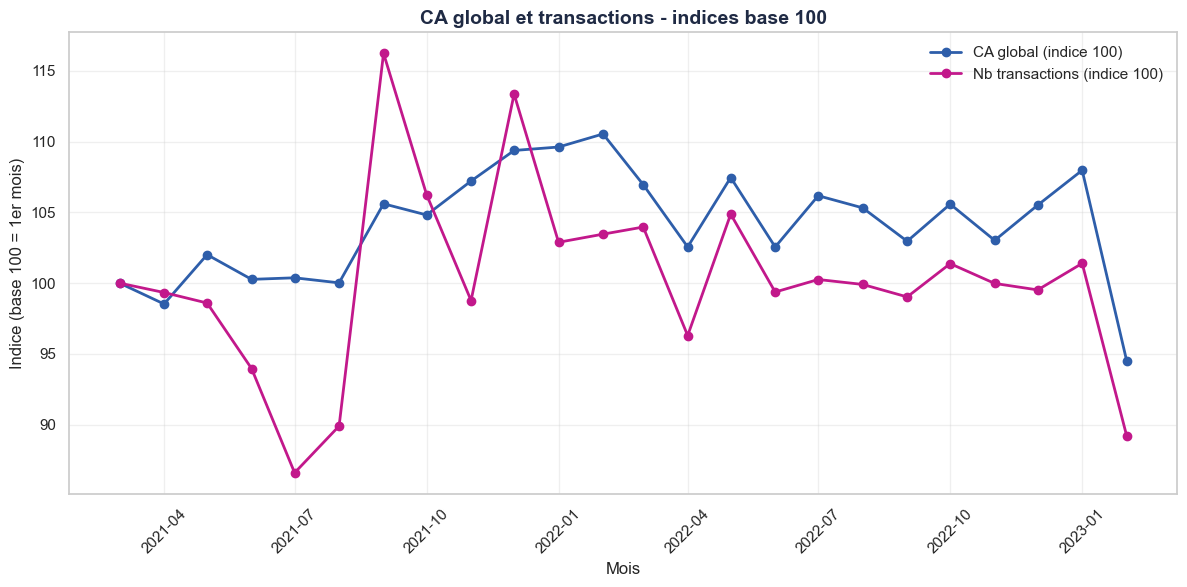

Nombre de mois compares : 24
Corr Pearson (CA global vs nb transactions) : 0.6749
Corr Spearman (CA global vs nb transactions) : 0.7296


In [52]:
# Nombre de transactions par mois (= nombre de lignes)
transactions_mois = transactions_btoc.groupby('mois_dt').size().reset_index(name='nb_transactions')

# CA global mensuel
ca_mensuel_global = transactions_btoc.groupby('mois_dt')['price'].sum().reset_index(name='ca_global')

# Fusion des indicateurs mensuels
volume_mois = (
    transactions_mois
    .merge(ca_mensuel_global, on='mois_dt')
    .sort_values('mois_dt')
)

# Corrélations avec le CA global mensuel
corr_ca_transactions_pearson = volume_mois['ca_global'].corr(volume_mois['nb_transactions'], method='pearson')
corr_ca_transactions_spearman = volume_mois['ca_global'].corr(volume_mois['nb_transactions'], method='spearman')

# Un seul graphique: comparaison en indices base 100
volume_mois['ca_idx100'] = volume_mois['ca_global'] / volume_mois['ca_global'].iloc[0] * 100
volume_mois['transactions_idx100'] = volume_mois['nb_transactions'] / volume_mois['nb_transactions'].iloc[0] * 100

fig8, ax = plt.subplots(figsize=(12, 6))
ax.plot(volume_mois['mois_dt'], volume_mois['ca_idx100'], marker='o', linewidth=2, label='CA global (indice 100)')
ax.plot(volume_mois['mois_dt'], volume_mois['transactions_idx100'], marker='o', linewidth=2, label='Nb transactions (indice 100)')

ax.set_title("CA global et transactions - indices base 100", fontsize=14)
ax.set_xlabel("Mois")
ax.set_ylabel("Indice (base 100 = 1er mois)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Nombre de mois compares : {len(volume_mois)}")
print(f"Corr Pearson (CA global vs nb transactions) : {corr_ca_transactions_pearson:.4f}")
print(f"Corr Spearman (CA global vs nb transactions) : {corr_ca_transactions_spearman:.4f}")


1️⃣ Le CA est <span style="color:#C2188B; font-weight:bold;">largement piloté par le volume de transactions</span>. Corrélation de spearman > 0,70 considérée comme fortement positive.
Les deux courbes évoluent globalement dans le même sens, donc quand le nombre de transactions monte, le CA monte aussi.

👉 Les dynamiques visuelles paraissent globalement alignées.

2️⃣ Le nombre de transactions est plus volatil que le CA.
La courbe transactions a des pics/creux plus marqués, alors que le CA est plus “lissé” : cela suggère <span style="color:#C2188B; font-weight:bold;">un effet de compensation par le panier moyen ou le mix produit</span>.

3️⃣ Il y a une phase de montée puis de stabilisation.
Après la hausse initiale, on observe plutôt un plateau autour de 2022, sans accélération durable du volume.
La chute de fin de période est probablement à interpréter avec prudence.
<span style="color:#C2188B; font-weight:bold;">La baisse simultanée sur le dernier point peut venir d’un mois incomplet (très fréquent dans ce type de séries)</span>.


👉 L'acquisition / activation clients en augmentant les transactions contribue à la performance
👉 Mais d'autres facteurs comptent aussi : panier moyen, mix produits, saisonnalité, promotions

# 6- 🏆 TOPS  versus FLOPS 

## 5.1 Tops versus Flops : CA par produit

Cette analyse compare les références qui génèrent le plus de chiffre d'affaires (Tops) à celles qui contribuent le moins (Flops).
L'objectif est d'identifier rapidement les produits moteurs, les produits secondaires et les références à arbitrer.

### Lecture attendue
- Les **Tops** représentent les produits à fort potentiel commercial : ils soutiennent la performance globale.
- Les **Flops** peuvent signaler un faible intérêt client, un mauvais positionnement prix, une faible visibilité ou un problème de stock.
- Un écart très important entre Tops et Flops indique une concentration du CA sur un nombre limité de références.

### Implications business
- Prioriser les Tops en merchandising, disponibilité et campagnes marketing ciblées.
- Diagnostiquer les Flops : saisonnalité, prix, qualité de la fiche produit, cannibalisation, ou faible rotation.
- Mettre en place une stratégie différenciée : **maintenir**, **relancer**, ou **déréférencer** selon la contribution et la marge.

👉 <span style="color:#C2188B; font-weight:bold;">Cette lecture aide à piloter le catalogue de manière plus rentable et à réduire le risque de dépendance à quelques produits phares</span>.

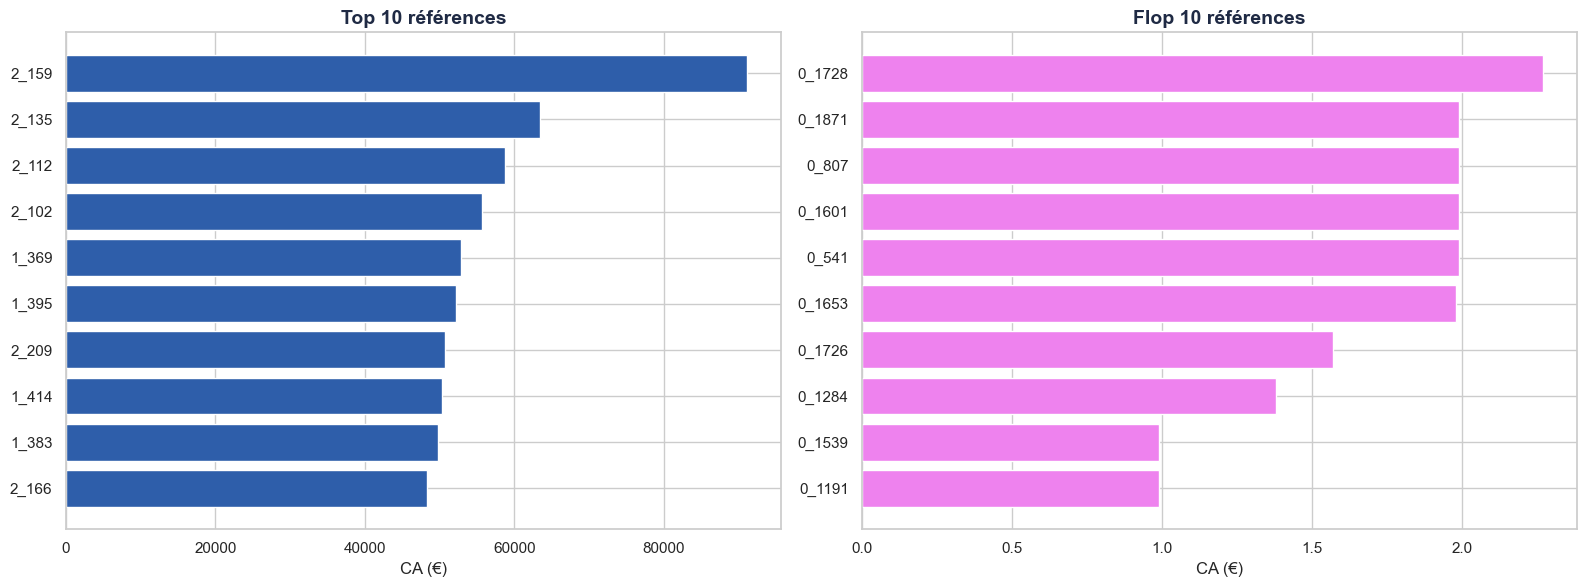

In [20]:
# CA par produit
ca_produit = transactions_btoc.groupby('id_prod')['price'].sum().reset_index()
ca_produit.columns = ['id_prod', 'ca']
ca_produit = ca_produit.sort_values('ca', ascending=False)

# Top 10
top10 = ca_produit.head(10)
# Flop 10
flop10 = ca_produit.tail(10)

# Graphique
fig9, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10['id_prod'], top10['ca'])
axes[0].set_title("Top 10 références", fontsize=14)
axes[0].set_xlabel("CA (€)")
axes[0].invert_yaxis()

axes[1].barh(flop10['id_prod'], flop10['ca'], color='violet')
axes[1].set_title("Flop 10 références", fontsize=14)
axes[1].set_xlabel("CA (€)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# 7- 📈 Courbe de Lorenz du chiffre d'affaires

La courbe de Lorenz permet de mesurer la **concentration** du chiffre d'affaires pour les clients BtoB et BtoC.
Elle compare la part cumulée de clients (axe X) à la part cumulée de CA (axe Y).

### Comment lire le graphique
- La diagonale représente une répartition parfaitement égalitaire du CA.
- <span style="color:#C2188B; font-weight:bold;">Plus la courbe de Lorenz est éloignée de la diagonale, plus la concentration est forte</span>.
- Le coefficient de Gini (affiché sur le graphique) synthétise ce niveau d'inégalité :
  - proche de **0** : répartition homogène
  - proche de **1** : forte concentration sur peu de clients

### Interprétation dans notre contexte
- Un Gini autour de **0,40** indique une concentration **modérée à marquée** du CA BtoC.
- La performance ne repose pas sur tous les clients de façon uniforme.
- <span style="color:#C2188B; font-weight:bold;">Il est pertinent de segmenter la base clients (fidèles, occasionnels, gros acheteurs) pour adapter les actions CRM</span>.

### Implications business
- <span style="color:#C2188B; font-weight:bold;">Sécuriser les clients à forte contribution (fidélisation, offres personnalisées)</span>.
- <span style="color:#C2188B; font-weight:bold;">Travailler l'activation des clients à faible contribution pour élargir la base de CA</span>.
- <span style="color:#C2188B; font-weight:bold;">Suivre l'évolution du Gini dans le temps pour détecter une dépendance croissante ou une meilleure diversification</span>.

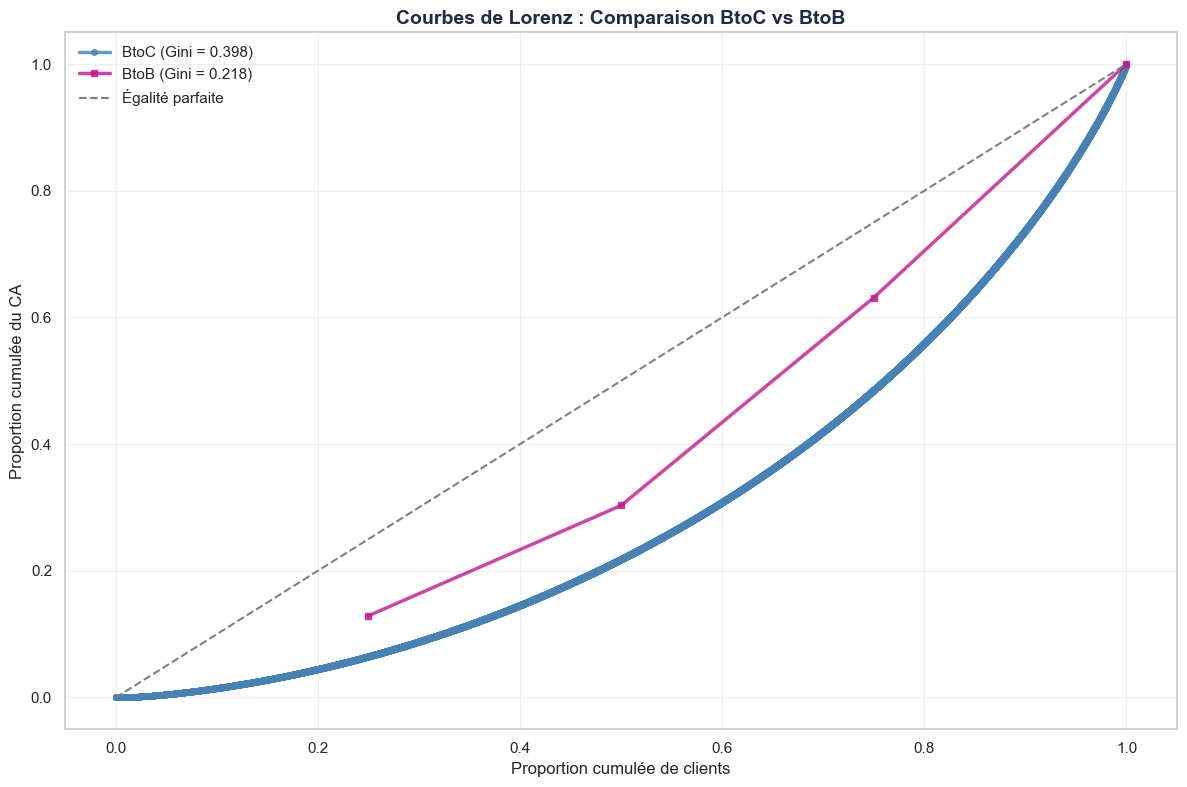

COMPARAISON DES COEFFICIENTS DE GINI

Clients BtoC : 8596 clients | Gini = 0.398
Clients BtoB : 4 clients | Gini = 0.218

Différence : 0.180

👉 Interprétation :
   Le Gini BtoC (0.398) > BtoB (0.218)
   → Le CA BtoC est PLUS concentré que le CA BtoB


In [41]:
# Courbe de Lorenz basee sur les datasets transactions_btoc et transactions_btob
ca_client_btoc = (
    transactions_btoc.groupby('client_id', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'ca_total'})
)

ca_client_btob = (
    transactions_btob.groupby('client_id', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'ca_total'})
)

# Calcul des courbes de Lorenz pour BtoC
values_btoc = np.sort(ca_client_btoc['ca_total'].values)
n_btoc = values_btoc.size
cum_values_btoc = np.cumsum(values_btoc) / values_btoc.sum()
cum_clients_btoc = np.arange(1, n_btoc + 1) / n_btoc
gini_btoc = (n_btoc + 1 - 2 * np.sum(np.cumsum(values_btoc)) / np.sum(values_btoc)) / n_btoc

# Calcul des courbes de Lorenz pour BtoB
values_btob = np.sort(ca_client_btob['ca_total'].values)
n_btob = values_btob.size
cum_values_btob = np.cumsum(values_btob) / values_btob.sum()
cum_clients_btob = np.arange(1, n_btob + 1) / n_btob
gini_btob = (n_btob + 1 - 2 * np.sum(np.cumsum(values_btob)) / np.sum(values_btob)) / n_btob

# Figure avec les deux courbes sur le même graphique
fig, ax = plt.subplots(figsize=(12, 8))

# Courbes de Lorenz
ax.plot(cum_clients_btoc, cum_values_btoc, label=f'BtoC (Gini = {gini_btoc:.3f})', 
        color='steelblue', linewidth=2.5, marker='o', markersize=4, alpha=0.8)
ax.plot(cum_clients_btob, cum_values_btob, label=f'BtoB (Gini = {gini_btob:.3f})', 
        color='#C2188B', linewidth=2.5, marker='s', markersize=4, alpha=0.8)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5, label='Égalité parfaite')

ax.set_xlabel('Proportion cumulée de clients', fontsize=12)
ax.set_ylabel('Proportion cumulée du CA', fontsize=12)
ax.set_title('Courbes de Lorenz : Comparaison BtoC vs BtoB', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Affichage des résultats
print("=" * 70)
print("COMPARAISON DES COEFFICIENTS DE GINI")
print("=" * 70)
print(f"\nClients BtoC : {len(ca_client_btoc)} clients | Gini = {gini_btoc:.3f}")
print(f"Clients BtoB : {len(ca_client_btob)} clients | Gini = {gini_btob:.3f}")
print(f"\nDifférence : {abs(gini_btob - gini_btoc):.3f}")
print("\n👉 Interprétation :")
if gini_btob > gini_btoc:
    print(f"   Le Gini BtoB ({gini_btob:.3f}) > BtoC ({gini_btoc:.3f})")
    print("   → Le CA BtoB est PLUS concentré que le CA BtoC")
else:
    print(f"   Le Gini BtoC ({gini_btoc:.3f}) > BtoB ({gini_btob:.3f})")
    print("   → Le CA BtoC est PLUS concentré que le CA BtoB")
print("=" * 70)

### Ce que le coefficient de Gini apporte en plus pour analyser la concentration du CA

La courbe de Lorenz donne une lecture visuelle très utile, mais <span style="color:#C2188B; font-weight:bold;">le coefficient de Gini ajoute une **mesure unique et comparable** de cette concentration</span>.

- La courbe montre la forme de l'inégalité ; le Gini la résume en un seul chiffre.
- Ce chiffre permet de comparer facilement plusieurs périodes (mois, trimestres, années).
- Il permet aussi de comparer des segments (BtoC vs BtoB, catégories de clients, zones géographiques).
- Le suivi du Gini dans le temps aide à détecter une dépendance croissante du CA à une minorité de clients.

Dans notre cas, un Gini autour de **0,40** indique une concentration modérée a marquee :
- le CA n'est pas réparti de manière homogène,
- une partie des clients contribue davantage que la moyenne,
- ce qui justifie des actions de fidélisation ciblée sur les clients à forte valeur et d'activation des clients à plus faible contribution.

👉 En synthèse : la courbe de Lorenz explique visuellement *comment* la concentration se forme, tandis que le Gini permet de mesurer *combien* elle est forte et de la piloter dans le temps. “Le Gini global est élevé car il intègre les grands comptes BtoB.”
“Pour le pilotage marketing, le bon KPI est le Gini BtoC, qui reflète la concentration de la base clients adressable par les actions marketing.”

In [42]:
# Diagnostic : détail des clients BtoB et distribution du CA
print("=" * 60)
print("DIAGNOSTIC : Détail des clients BtoB")
print("=" * 60)

# Synthèse des clients BtoB
print(f"\nNombre total de clients BtoB : {len(ca_client_btob)}")
print(f"\nCA par client BtoB (en €) :")
print(ca_client_btob.sort_values('ca_total', ascending=False).to_string(index=False))

# Statistiques
ca_btob = ca_client_btob['ca_total'].values
print(f"\nStatistiques du CA BtoB :")
print(f"  CA min : {ca_btob.min():,.0f} €")
print(f"  CA max : {ca_btob.max():,.0f} €")
print(f"  CA moyen : {ca_btob.mean():,.0f} €")
print(f"  CA médian : {np.median(ca_btob):,.0f} €")
print(f"  CA total : {ca_btob.sum():,.0f} €")

# Concentration
ca_sorted = np.sort(ca_btob)
ca_cum_pct = np.cumsum(ca_sorted) / ca_sorted.sum() * 100
print(f"\nConcentration du CA BtoB :")
for i, (ca, cum_pct) in enumerate(zip(ca_sorted, ca_cum_pct), 1):
    print(f"  Client {i} : {ca:,.0f} € ({cum_pct:.1f}% cumulé)")

print(f"\nCoefficient de Gini BtoB : {gini_btob:.3f}")
print("\n👉 Interprétation : Un Gini de 0,57 indique que le CA BtoB")
print("   est très concentré sur peu de clients (inégalité forte).")


DIAGNOSTIC : Détail des clients BtoB

Nombre total de clients BtoB : 4

CA par client BtoB (en €) :
client_id  ca_total
   c_1609 326039.89
   c_4958 290227.03
   c_6714 153918.60
   c_3454 114110.57

Statistiques du CA BtoB :
  CA min : 114,111 €
  CA max : 326,040 €
  CA moyen : 221,074 €
  CA médian : 222,073 €
  CA total : 884,296 €

Concentration du CA BtoB :
  Client 1 : 114,111 € (12.9% cumulé)
  Client 2 : 153,919 € (30.3% cumulé)
  Client 3 : 290,227 € (63.1% cumulé)
  Client 4 : 326,040 € (100.0% cumulé)

Coefficient de Gini BtoB : 0.218

👉 Interprétation : Un Gini de 0,57 indique que le CA BtoB
   est très concentré sur peu de clients (inégalité forte).


# 8 - 🎯 Stratégie Différenciée : Segmentation et Pilotage

## 8.1 Sécuriser les clients BtoB à forte contribution

La stratégie BtoB repose sur la fidélisation des clients majeurs puisque le segment sont très concentrés (peu de gros clients).
- 🔒 Clients à forte contribution : fidélisation, offres personnalisées, account management dédié
- 📊 Clients à contribution modérée : augmenter le panier moyen
- 📈 Clients à faible contribution : activation, nouvelles offres, augmenter la fréquence

## 8.2 Activation des clients BtoC à faible contribution

Pour les clients BtoC, l'enjeu est d'élargir la base de CA, car beaucoup sont des clients occasionnels.
- 💡 Identifier les clients "dormants" ou "très légers"
- 🎁 Actions d'activation : offres ciblées, newsletters, fidélisation progressive
- 📈 Objectif : augmenter le nombre de clients actifs et la fréquence d'achat

## 8.3 Suivi temporel du Gini BtoC

Déterminer si la concentration du CA BtoC augmente ou diminue dans le temps.
- 📉 Gini croissant → dépendance accrue, risque de concentration
- 📈 Gini décroissant → meilleure diversification du portefeuille clients

SEGMENTATION CLIENTS BtoB PAR CONTRIBUTION


,Rang,Client ID,CA Total (€),Part CA (%),Cumule (%),Segment
0,1,c_1609,"326,040",36.9%,36.9%,Fort
1,2,c_4958,"290,227",32.8%,69.7%,Fort
2,3,c_6714,"153,919",17.4%,87.1%,Faible
3,4,c_3454,"114,111",12.9%,100.0%,Faible



RESUME PAR SEGMENT BtoB


,Segment,Nb Clients,CA Segment (€),Part CA (%),CA Moyen (€)
0,Faible,2,"268,029",30.3%,"134,015"
1,Fort,2,"616,267",69.7%,"308,133"


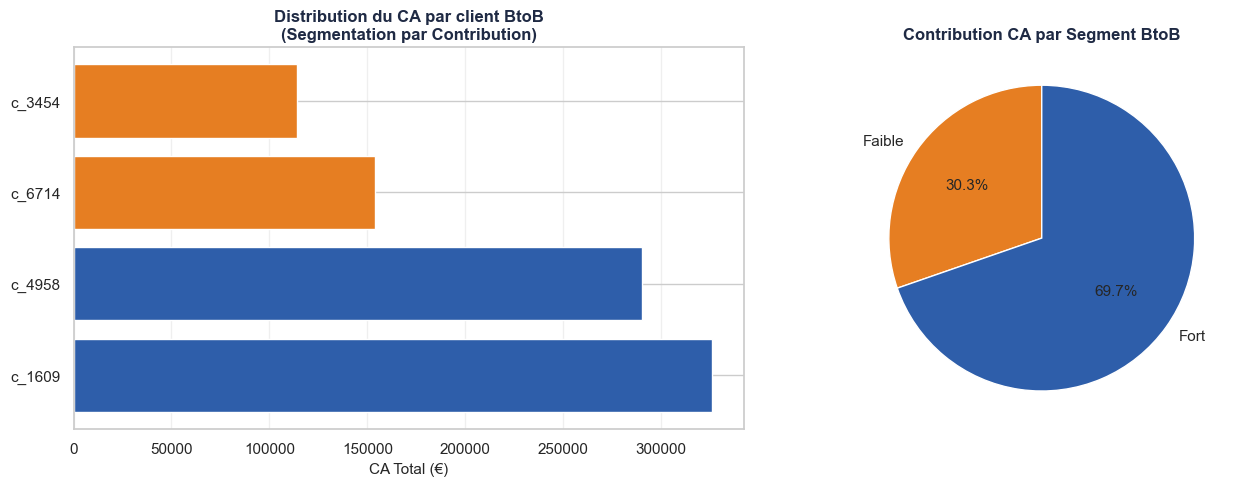


✅ Segmentation BtoB completee


In [54]:
# ============================================================================
# 8.1 - SEGMENTATION DES CLIENTS BtoB PAR CONTRIBUTION
# ============================================================================

# Classement des clients BtoB par contribution
ca_client_btob_detail = (
    transactions_btob.groupby('client_id', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'ca_total'})
    .sort_values('ca_total', ascending=False)
    .reset_index(drop=True)
)

ca_client_btob_detail['rank'] = ca_client_btob_detail.index + 1
ca_client_btob_detail['ca_cumsum'] = ca_client_btob_detail['ca_total'].cumsum()
ca_client_btob_detail['ca_pct_total'] = ca_client_btob_detail['ca_total'] / ca_client_btob_detail['ca_total'].sum() * 100
ca_client_btob_detail['ca_pct_cumsum'] = ca_client_btob_detail['ca_pct_total'].cumsum()

# Segmentation par quartiles ou par logique metier
if len(ca_client_btob_detail) <= 5:
    ca_client_btob_detail['segment_contribution'] = pd.cut(
        ca_client_btob_detail['ca_total'],
        bins=3,
        labels=['Faible', 'Moyen', 'Fort']
    )
else:
    ca_client_btob_detail['segment_contribution'] = pd.qcut(
        ca_client_btob_detail['ca_total'],
        q=3,
        labels=['Faible', 'Moyen', 'Fort'],
        duplicates='drop'
    )

print("=" * 80)
print("SEGMENTATION CLIENTS BtoB PAR CONTRIBUTION")
print("=" * 80)
display(ca_client_btob_detail[[
    'rank', 'client_id', 'ca_total', 'ca_pct_total', 'ca_pct_cumsum', 'segment_contribution'
]].rename(columns={
    'rank': 'Rang',
    'client_id': 'Client ID',
    'ca_total': 'CA Total (€)',
    'ca_pct_total': 'Part CA (%)',
    'ca_pct_cumsum': 'Cumule (%)',
    'segment_contribution': 'Segment'
}).style.format({
    'CA Total (€)': '{:,.0f}',
    'Part CA (%)': '{:.1f}%',
    'Cumule (%)': '{:.1f}%'
}))

# Resume par segment
segmentation_btob = (
    ca_client_btob_detail.groupby('segment_contribution', observed=True)
    .agg({
        'client_id': 'count',
        'ca_total': 'sum'
    })
    .rename(columns={'client_id': 'nb_clients', 'ca_total': 'ca_segment'})
    .reset_index()
)
segmentation_btob['part_ca_pct'] = segmentation_btob['ca_segment'] / segmentation_btob['ca_segment'].sum() * 100
segmentation_btob['ca_moyen'] = segmentation_btob['ca_segment'] / segmentation_btob['nb_clients']

print("\n" + "=" * 80)
print("RESUME PAR SEGMENT BtoB")
print("=" * 80)
display(segmentation_btob.rename(columns={
    'segment_contribution': 'Segment',
    'nb_clients': 'Nb Clients',
    'ca_segment': 'CA Segment (€)',
    'part_ca_pct': 'Part CA (%)',
    'ca_moyen': 'CA Moyen (€)'
}).style.format({
    'CA Segment (€)': '{:,.0f}',
    'Part CA (%)': '{:.1f}%',
    'CA Moyen (€)': '{:,.0f}'
}))

# Visualisation
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Mapping couleur unique par segment (utilise partout)
colors_segment = {'Fort': '#2E5EAA', 'Moyen': '#2E8B57', 'Faible': '#E67E22'}

# Graphique 1 : Distribution du CA par client BtoB
colors = ca_client_btob_detail['segment_contribution'].map(colors_segment)
ax[0].barh(ca_client_btob_detail['client_id'].astype(str), ca_client_btob_detail['ca_total'], color=colors)
ax[0].set_xlabel('CA Total (€)', fontsize=11)
ax[0].set_title('Distribution du CA par client BtoB\n(Segmentation par Contribution)', fontsize=12, fontweight='bold')
ax[0].grid(True, alpha=0.3, axis='x')

# Graphique 2 : Pie chart par segment (meme mapping de couleurs)
segmentation_sorted = segmentation_btob.sort_values('segment_contribution').copy()
pie_colors = [colors_segment.get(str(seg), '#7F8C8D') for seg in segmentation_sorted['segment_contribution']]
ax[1].pie(
    segmentation_sorted['ca_segment'],
    labels=segmentation_sorted['segment_contribution'],
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    textprops={'fontsize': 11}
)
ax[1].set_title('Contribution CA par Segment BtoB', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Segmentation BtoB completee")

DIAGNOSTIC ACTIVATION - CLIENTS BtoC À FAIBLE CONTRIBUTION

📊 DISTRIBUTION PAR SEGMENT DE CA (BtoC)
  - Très Faible : 2149 clients, CA total : 723,660€
  - Faible : 2149 clients, CA total : 1,710,284€
  - Moyen : 2149 clients, CA total : 2,975,993€
  - Fort : 2149 clients, CA total : 5,733,430€

🎯 PROFILS À ACTIVER
  - Très légers (<100€, <3 mois) : 22 clients, CA total : 890€
  - Dormants (>60j inactifs) : 8574 clients, CA total : 11,142,477€


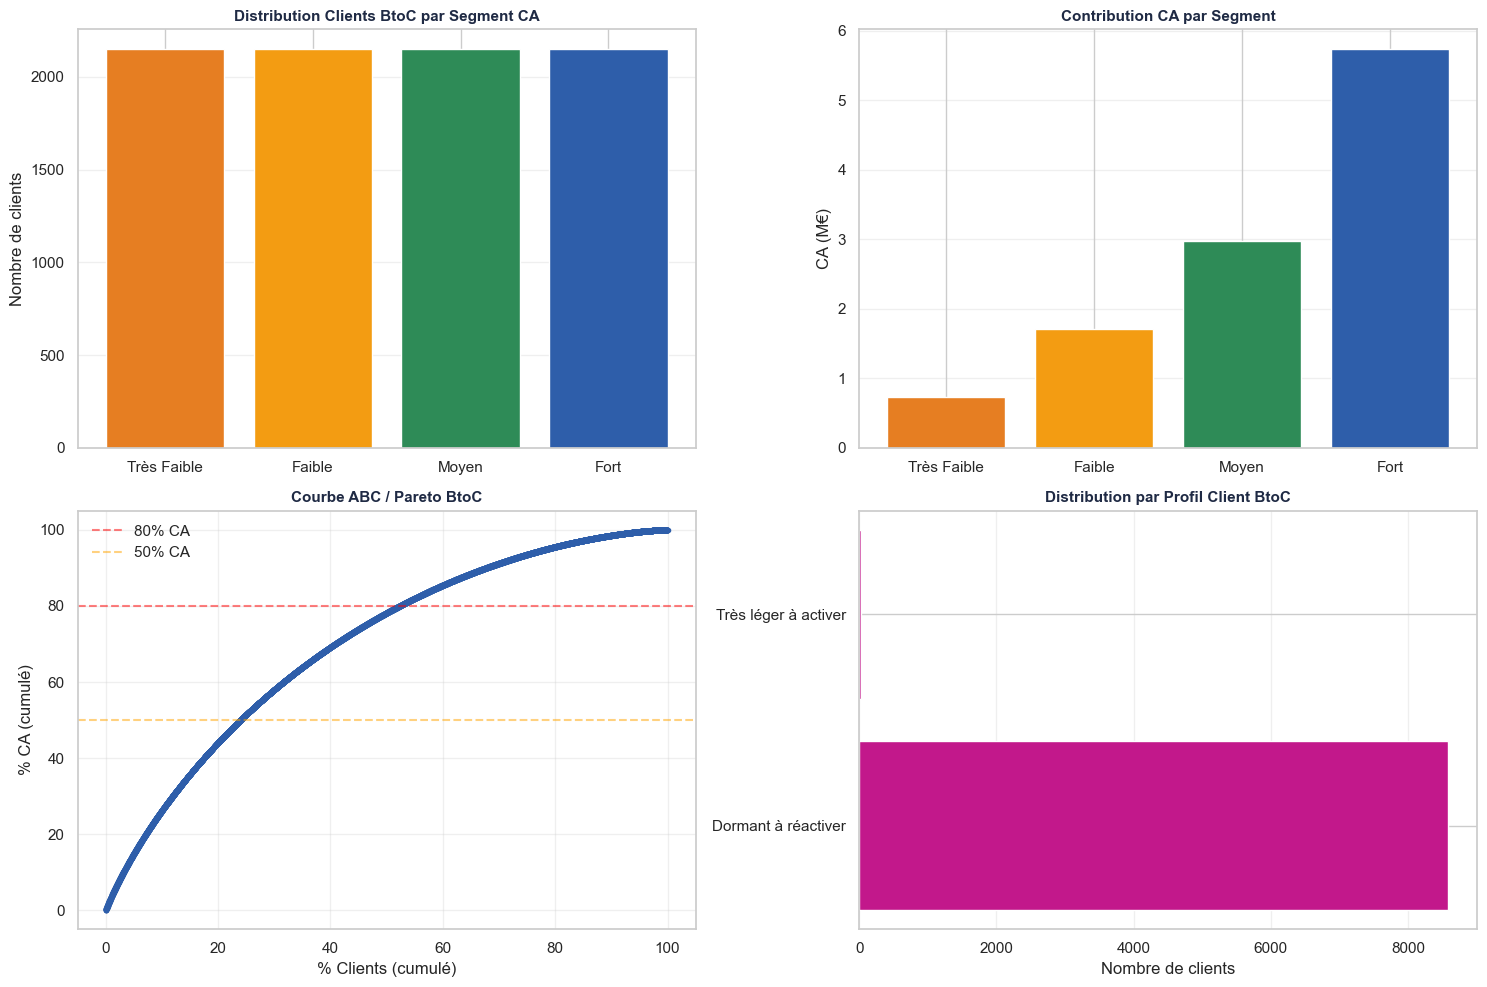


✅ Diagnostic activation clients complété


In [44]:
# ============================================================================
# 8.2 - DIAGNOSTIC DES CLIENTS À FAIBLE CONTRIBUTION (BtoC et BtoB)
# ============================================================================

# CLIENT BtoC : Identification des profils à activer
print("=" * 80)
print("DIAGNOSTIC ACTIVATION - CLIENTS BtoC À FAIBLE CONTRIBUTION")
print("=" * 80)

# Créer les dataframes correctement pour éviter les multiindex
ca_client_btoc_agg = transactions_btoc.groupby('client_id')['price'].agg(['sum', 'count', 'mean']).reset_index()
ca_client_btoc_dates = transactions_btoc.groupby('client_id')['date'].agg(['min', 'max']).reset_index()
ca_client_btoc_detail = ca_client_btoc_agg.merge(ca_client_btoc_dates, on='client_id')
ca_client_btoc_detail.columns = ['client_id', 'ca_total', 'nb_transactions', 'panier_moyen', 'date_premiere', 'date_derniere']
ca_client_btoc_detail['date_premiere'] = pd.to_datetime(ca_client_btoc_detail['date_premiere'])
ca_client_btoc_detail['date_derniere'] = pd.to_datetime(ca_client_btoc_detail['date_derniere'])
ca_client_btoc_detail['jours_actifs'] = (ca_client_btoc_detail['date_derniere'] - ca_client_btoc_detail['date_premiere']).dt.days
ca_client_btoc_detail['recence_jours'] = (pd.Timestamp.now() - ca_client_btoc_detail['date_derniere']).dt.days

# Segmentation BtoC par quartiles de CA
ca_client_btoc_detail['segment_ca'] = pd.qcut(
    ca_client_btoc_detail['ca_total'],
    q=4,
    labels=['Très Faible', 'Faible', 'Moyen', 'Fort'],
    duplicates='drop'
)

# Profil dormant : inactif depuis plus de 60 jours
ca_client_btoc_detail['statut_recence'] = ca_client_btoc_detail['recence_jours'].apply(
    lambda x: 'Dormant (>60j)' if x > 60 else ('Inactif (30-60j)' if x > 30 else 'Actif (<30j)')
)

# Clients très légers : CA < 100€ ET actif < 3 mois
ca_client_btoc_detail['profil'] = ca_client_btoc_detail.apply(
    lambda row: 'Très léger à activer' if (row['ca_total'] < 100 and row['jours_actifs'] < 90) 
    else ('Dormant à réactiver' if row['recence_jours'] > 60 
    else ('Occasionnel fidéliser' if row['nb_transactions'] < 3 
    else 'Client standard')),
    axis=1
)

# Analyse des clients à faible contribution
faibles_contribution = ca_client_btoc_detail[ca_client_btoc_detail['segment_ca'] == 'Très Faible'].copy()
tres_legers = ca_client_btoc_detail[ca_client_btoc_detail['profil'] == 'Très léger à activer'].copy()
dormants = ca_client_btoc_detail[ca_client_btoc_detail['profil'] == 'Dormant à réactiver'].copy()

print(f"\n📊 DISTRIBUTION PAR SEGMENT DE CA (BtoC)")
print(f"  - Très Faible : {len(ca_client_btoc_detail[ca_client_btoc_detail['segment_ca'] == 'Très Faible'])} clients, "
      f"CA total : {ca_client_btoc_detail[ca_client_btoc_detail['segment_ca'] == 'Très Faible']['ca_total'].sum():,.0f}€")
print(f"  - Faible : {len(ca_client_btoc_detail[ca_client_btoc_detail['segment_ca'] == 'Faible'])} clients, "
      f"CA total : {ca_client_btoc_detail[ca_client_btoc_detail['segment_ca'] == 'Faible']['ca_total'].sum():,.0f}€")
print(f"  - Moyen : {len(ca_client_btoc_detail[ca_client_btoc_detail['segment_ca'] == 'Moyen'])} clients, "
      f"CA total : {ca_client_btoc_detail[ca_client_btoc_detail['segment_ca'] == 'Moyen']['ca_total'].sum():,.0f}€")
print(f"  - Fort : {len(ca_client_btoc_detail[ca_client_btoc_detail['segment_ca'] == 'Fort'])} clients, "
      f"CA total : {ca_client_btoc_detail[ca_client_btoc_detail['segment_ca'] == 'Fort']['ca_total'].sum():,.0f}€")

print(f"\n🎯 PROFILS À ACTIVER")
print(f"  - Très légers (<100€, <3 mois) : {len(tres_legers)} clients, "
      f"CA total : {tres_legers['ca_total'].sum():,.0f}€")
print(f"  - Dormants (>60j inactifs) : {len(dormants)} clients, "
      f"CA total : {dormants['ca_total'].sum():,.0f}€")

# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribution par segment de CA
segment_counts = ca_client_btoc_detail['segment_ca'].value_counts().sort_index()
segment_ca = ca_client_btoc_detail.groupby('segment_ca', observed=True)['ca_total'].sum()
axes[0, 0].bar(segment_counts.index, segment_counts.values, color=['#E67E22', '#F39C12', '#2E8B57', '#2E5EAA'])
axes[0, 0].set_title('Distribution Clients BtoC par Segment CA', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Nombre de clients')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Contribution CA par segment
axes[0, 1].bar(segment_ca.index, segment_ca.values / 1e6, color=['#E67E22', '#F39C12', '#2E8B57', '#2E5EAA'])
axes[0, 1].set_title('Contribution CA par Segment', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('CA (M€)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Pareto : clients cumulés vs CA cumulé
ca_sorted = ca_client_btoc_detail['ca_total'].sort_values(ascending=False).reset_index(drop=True)
ca_cumsum = ca_sorted.cumsum()
ca_total = ca_sorted.sum()
pct_cumsum = (ca_cumsum / ca_total * 100).values
pct_clients = (np.arange(len(ca_sorted)) + 1) / len(ca_sorted) * 100

axes[1, 0].plot(pct_clients, pct_cumsum, marker='o', linewidth=2, markersize=3)
axes[1, 0].axhline(80, color='red', linestyle='--', alpha=0.5, label='80% CA')
axes[1, 0].axhline(50, color='orange', linestyle='--', alpha=0.5, label='50% CA')
axes[1, 0].set_xlabel('% Clients (cumulé)')
axes[1, 0].set_ylabel('% CA (cumulé)')
axes[1, 0].set_title('Courbe ABC / Pareto BtoC', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Distribution par profil
profil_counts = ca_client_btoc_detail['profil'].value_counts()
axes[1, 1].barh(profil_counts.index, profil_counts.values, color='#C2188B')
axes[1, 1].set_title('Distribution par Profil Client BtoC', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Nombre de clients')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✅ Diagnostic activation clients complété")

SUIVI TEMPOREL DU GINI BtoC - ANALYSE DE LA DÉPENDANCE CLIENTS

📈 ÉVOLUTION DU GINI BtoC
  Gini initial (1er trimestre) : 0.430
  Gini final (dernier trimestre) : 0.445
  Variation : 0.015
  ⚠️  TENDANCE : Gini CROISSANT → Dépendance client AUGMENTE
  Pente tendance linéaire : 0.0014
  📊 STABILITÉ : Gini quasi-stable dans le temps

📊 DÉTAIL PAR TRIMESTRE


,Trimestre,Gini,Clients Actifs,CA Total (€)
0,2021-01 (Q1),0.430,5672,"445,919"
1,2021-04 (Q2),0.438,7828,"1,341,327"
2,2021-07 (Q3),0.438,7827,"1,364,517"
3,2021-10 (Q4),0.419,8011,"1,433,213"
4,2022-01 (Q1),0.432,7730,"1,458,686"
5,2022-04 (Q2),0.438,7766,"1,393,827"
6,2022-07 (Q3),0.440,7736,"1,402,213"
7,2022-10 (Q4),0.438,7722,"1,400,695"
8,2023-01 (Q1),0.445,7081,"902,970"


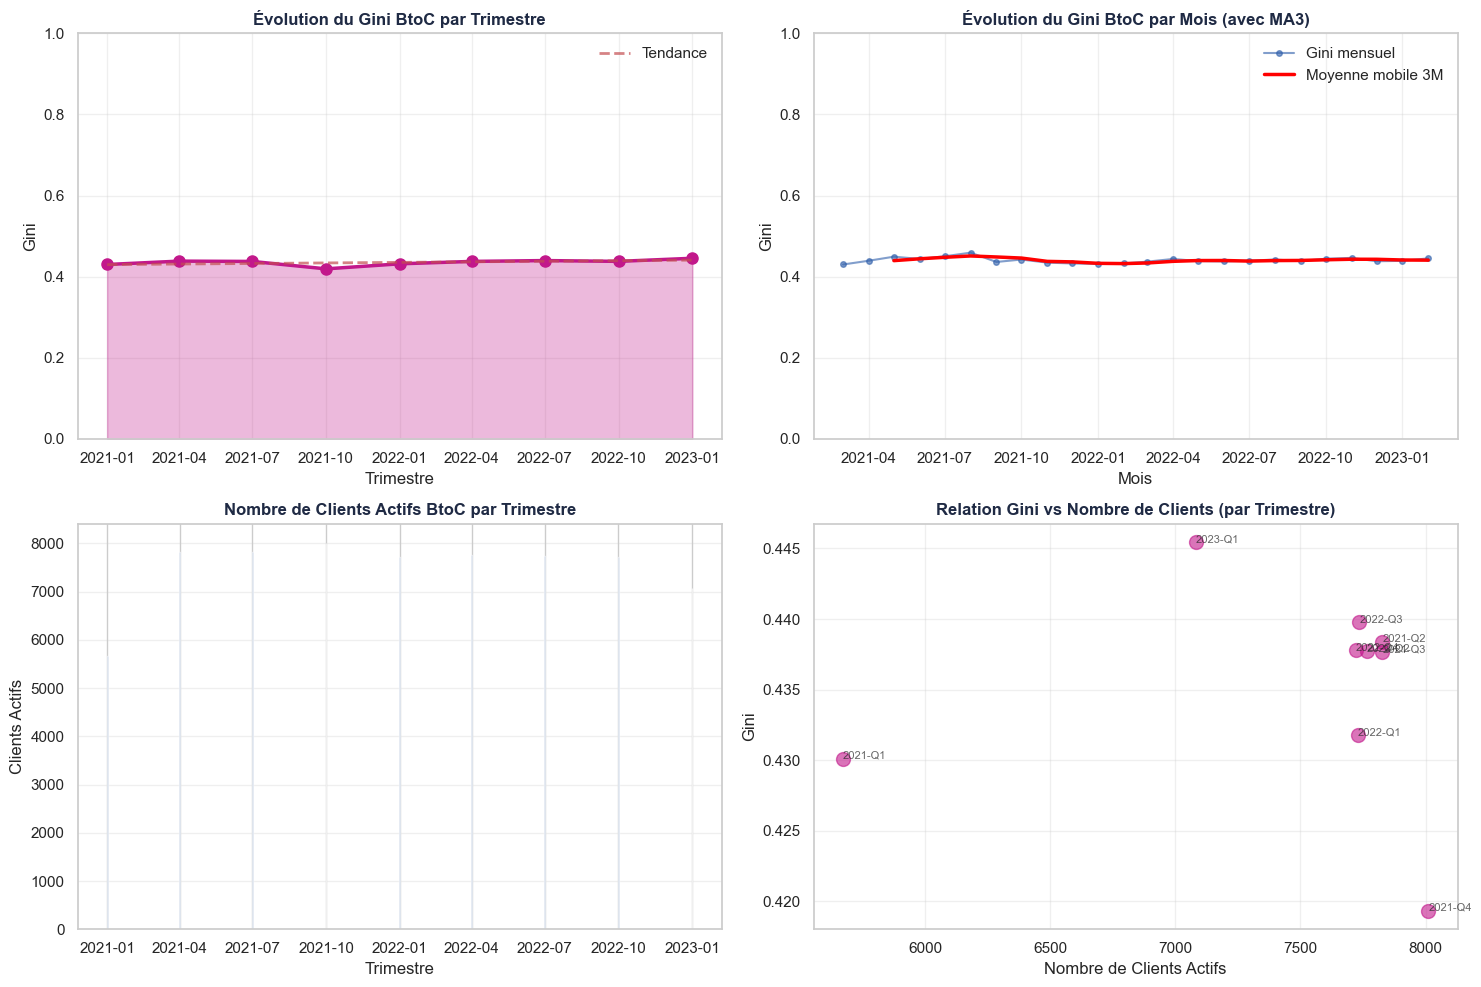


✅ Suivi temporel du Gini complété


In [45]:
# ============================================================================
# 8.3 - SUIVI TEMPOREL DU GINI BtoC (Dépendance croissante vs Diversification)
# ============================================================================

print("=" * 80)
print("SUIVI TEMPOREL DU GINI BtoC - ANALYSE DE LA DÉPENDANCE CLIENTS")
print("=" * 80)

# Calcul du Gini par trimestre pour une fine granularité
transactions_btoc['trimestre'] = transactions_btoc['date'].dt.to_period('Q').dt.to_timestamp()
trimestres = sorted(transactions_btoc['trimestre'].unique())

gini_par_trimestre = []

for trim in trimestres:
    tx_trim = transactions_btoc[transactions_btoc['trimestre'] == trim]
    ca_trim = tx_trim.groupby('client_id')['price'].sum().values
    
    if len(ca_trim) > 0:
        ca_trim_sorted = np.sort(ca_trim)
        n = len(ca_trim_sorted)
        gini = (n + 1 - 2 * np.sum(np.cumsum(ca_trim_sorted)) / np.sum(ca_trim_sorted)) / n
        nb_clients = n
        ca_total = ca_trim.sum()
    else:
        gini = np.nan
        nb_clients = 0
        ca_total = 0
    
    gini_par_trimestre.append({
        'trimestre': trim,
        'gini': gini,
        'nb_clients': nb_clients,
        'ca_total': ca_total
    })

gini_df = pd.DataFrame(gini_par_trimestre).dropna()

# Calcul du Gini par mois pour une granularité plus fine
transactions_btoc['mois_dt_gini'] = transactions_btoc['date'].dt.to_period('M').dt.to_timestamp()
mois_list = sorted(transactions_btoc['mois_dt_gini'].unique())

gini_par_mois = []

for mois in mois_list:
    tx_mois = transactions_btoc[transactions_btoc['mois_dt_gini'] == mois]
    ca_mois = tx_mois.groupby('client_id')['price'].sum().values
    
    if len(ca_mois) > 0:
        ca_mois_sorted = np.sort(ca_mois)
        n = len(ca_mois_sorted)
        gini = (n + 1 - 2 * np.sum(np.cumsum(ca_mois_sorted)) / np.sum(ca_mois_sorted)) / n
        nb_clients = n
        ca_total = ca_mois.sum()
    else:
        gini = np.nan
        nb_clients = 0
        ca_total = 0
    
    gini_par_mois.append({
        'mois': mois,
        'gini': gini,
        'nb_clients': nb_clients,
        'ca_total': ca_total
    })

gini_mois_df = pd.DataFrame(gini_par_mois).dropna()

# Statistiques
print(f"\n📈 ÉVOLUTION DU GINI BtoC")
print(f"  Gini initial (1er trimestre) : {gini_df.iloc[0]['gini']:.3f}")
print(f"  Gini final (dernier trimestre) : {gini_df.iloc[-1]['gini']:.3f}")
print(f"  Variation : {(gini_df.iloc[-1]['gini'] - gini_df.iloc[0]['gini']):.3f}")

if gini_df.iloc[-1]['gini'] > gini_df.iloc[0]['gini']:
    print(f"  ⚠️  TENDANCE : Gini CROISSANT → Dépendance client AUGMENTE")
else:
    print(f"  ✅ TENDANCE : Gini DÉCROISSANT → Meilleure diversification")

# Analyse tendance
gini_trend = np.polyfit(range(len(gini_df)), gini_df['gini'].values, 1)[0]
print(f"  Pente tendance linéaire : {gini_trend:.4f}")
if abs(gini_trend) < 0.01:
    print(f"  📊 STABILITÉ : Gini quasi-stable dans le temps")
elif gini_trend > 0:
    print(f"  ⚠️  DÉGRADATION : Concentration s'accentue chaque trimestre")
else:
    print(f"  ✅ AMÉLIORATION : Concentration diminue progressivement")

# Tableau détaillé
print(f"\n📊 DÉTAIL PAR TRIMESTRE")
gini_df_display = gini_df.copy()
gini_df_display['trimestre_str'] = gini_df_display['trimestre'].dt.strftime('%Y-%m') + ' (Q' + ((gini_df_display['trimestre'].dt.month + 2) // 3).astype(str) + ')'
display(gini_df_display[[
    'trimestre_str', 'gini', 'nb_clients', 'ca_total'
]].rename(columns={
    'trimestre_str': 'Trimestre',
    'gini': 'Gini',
    'nb_clients': 'Clients Actifs',
    'ca_total': 'CA Total (€)'
}).style.format({
    'Gini': '{:.3f}',
    'CA Total (€)': '{:,.0f}'
}))

# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Évolution du Gini (trimestriel)
axes[0, 0].plot(gini_df['trimestre'], gini_df['gini'], marker='o', linewidth=2.5, markersize=8, color='#C2188B')
axes[0, 0].fill_between(gini_df['trimestre'], gini_df['gini'], alpha=0.3, color='#C2188B')
# Ligne de tendance
z = np.polyfit(range(len(gini_df)), gini_df['gini'].values, 1)
p = np.poly1d(z)
axes[0, 0].plot(gini_df['trimestre'], p(range(len(gini_df))), 'r--', linewidth=2, alpha=0.7, label='Tendance')
axes[0, 0].set_title('Évolution du Gini BtoC par Trimestre', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Gini')
axes[0, 0].set_xlabel('Trimestre')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])

# 2. Évolution du Gini (mensuel) avec moyenne mobile
axes[0, 1].plot(gini_mois_df['mois'], gini_mois_df['gini'], marker='o', linewidth=1.5, markersize=4, alpha=0.6, label='Gini mensuel')
gini_mois_df['gini_ma3'] = gini_mois_df['gini'].rolling(window=3).mean()
axes[0, 1].plot(gini_mois_df['mois'], gini_mois_df['gini_ma3'], linewidth=2.5, color='red', label='Moyenne mobile 3M')
axes[0, 1].set_title('Évolution du Gini BtoC par Mois (avec MA3)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Gini')
axes[0, 1].set_xlabel('Mois')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])

# 3. Nombre de clients actifs BtoC par trimestre
axes[1, 0].bar(gini_df['trimestre'], gini_df['nb_clients'], color='#2E5EAA', alpha=0.7)
axes[1, 0].set_title('Nombre de Clients Actifs BtoC par Trimestre', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Clients Actifs')
axes[1, 0].set_xlabel('Trimestre')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Relation Gini vs Nombre de clients
axes[1, 1].scatter(gini_df['nb_clients'], gini_df['gini'], s=100, alpha=0.6, color='#C2188B')
for idx, row in gini_df.iterrows():
    q_num = (row['trimestre'].month + 2) // 3
    axes[1, 1].annotate(f"{row['trimestre'].year}-Q{q_num}", 
                       (row['nb_clients'], row['gini']),
                       fontsize=8, alpha=0.7)
axes[1, 1].set_xlabel('Nombre de Clients Actifs')
axes[1, 1].set_ylabel('Gini')
axes[1, 1].set_title('Relation Gini vs Nombre de Clients (par Trimestre)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Suivi temporel du Gini complété")

In [46]:
# ============================================================================
# 8.4 - PLAN D'ACTION STRATÉGIQUE DIFFÉRENCIÉ
# ============================================================================

print("=" * 80)
print("SYNTHÈSE STRATÉGIQUE : RECOMMANDATIONS PAR SEGMENT")
print("=" * 80)

# SYNTHÈSE GLOBALE
print(f"\n🎯 VUE D'ENSEMBLE")
print(f"  • Clients BtoB : {len(ca_client_btob_detail)} clients | Gini = {gini_btob:.3f} (Très concentré)")
print(f"  • Clients BtoC : {len(ca_client_btoc_detail)} clients | Gini = {gini_btoc:.3f} (Modérément concentré)")
print(f"  • Concentration globale : BtoC {abs(gini_btoc - gini_btob):.3f} points plus concentré que BtoB")

# ============================================================================
# STRATÉGIE BtoB : SÉCURISATION ET FIDÉLISATION
# ============================================================================
print(f"\n{'='*80}")
print("📌 STRATÉGIE BtoB : SÉCURISATION DES CLIENTS À FORTE CONTRIBUTION")
print(f"{'='*80}")

# Vérifier qu'on a les données définies
if 'segmentation_btob' in locals() and 'tres_legers' in locals():
    strong_clients = segmentation_btob[segmentation_btob['segment_contribution'] == 'Fort']
    if len(strong_clients) > 0:
        strong_ca = strong_clients['ca_segment'].values[0]
        strong_pct = strong_clients['part_ca_pct'].values[0]
        strong_count = strong_clients['nb_clients'].values[0]
    
    print(f"\n🔒 CLIENTS FORTS (1️⃣ Fidélisation)")
    print(f"   Nombre : {strong_count} clients")
    print(f"   CA : {strong_ca:,.0f}€ ({strong_pct:.1f}% du CA BtoB)")
    print(f"   CA moyen : {strong_ca/strong_count:,.0f}€")
    print(f"\n   ✅ Actions recommandées :")
    print(f"      • Account Management dédié (contact régulier)")
    print(f"      • Conditions commerciales exclusives")
    print(f"      • Offres produits personnalisées")
    print(f"      • Suivi mensuel de satisfaction")
    print(f"      • Co-création d'offres spécifiques")

medium_clients = segmentation_btob[segmentation_btob['segment_contribution'] == 'Moyen']
if len(medium_clients) > 0:
    medium_ca = medium_clients['ca_segment'].values[0]
    medium_pct = medium_clients['part_ca_pct'].values[0]
    medium_count = medium_clients['nb_clients'].values[0]
    
    print(f"\n📈 CLIENTS MOYENS (2️⃣ Croissance)")
    print(f"   Nombre : {medium_count} client(s)")
    print(f"   CA : {medium_ca:,.0f}€ ({medium_pct:.1f}% du CA BtoB)")
    print(f"   CA moyen : {medium_ca/medium_count:,.0f}€")
    print(f"\n   ✅ Actions recommandées :")
    print(f"      • Augmenter le panier moyen : cross-sell, nouveaux produits")
    print(f"      • Augmenter la fréquence d'achat")
    print(f"      • Proposer de packs/contrats annuels")
    print(f"      • Formations clients sur offres")

weak_clients = segmentation_btob[segmentation_btob['segment_contribution'] == 'Faible']
if len(weak_clients) > 0:
    weak_ca = weak_clients['ca_segment'].values[0]
    weak_pct = weak_clients['part_ca_pct'].values[0]
    weak_count = weak_clients['nb_clients'].values[0]
    
    print(f"\n📊 CLIENTS FAIBLES (3️⃣ Activation)")
    print(f"   Nombre : {weak_count} client(s)")
    print(f"   CA : {weak_ca:,.0f}€ ({weak_pct:.1f}% du CA BtoB)")
    print(f"   CA moyen : {weak_ca/weak_count:,.0f}€")
    print(f"\n   ✅ Actions recommandées :")
    print(f"      • Diagnostiquer le faible engagement (usages, barrières)")
    print(f"      • Proposer nouvelles solutions adaptées")
    print(f"      • Audit des besoins client")
    print(f"      • Potentiel de croissance : {weak_ca * 2:,.0f}€ (doublement du CA)")

# ============================================================================
# STRATÉGIE BtoC : ACTIVATION ET SUIVI
# ============================================================================
print(f"\n{'='*80}")
print("📌 STRATÉGIE BtoC : ACTIVATION ET DIVERSIFICATION")
print(f"{'='*80}")

print(f"\n💡 CLIENTS TRÈS LÉGERS À ACTIVER (Potentiel d'acquisition)")
print(f"   Nombre : {len(tres_legers)} clients")
print(f"   CA total : {tres_legers['ca_total'].sum():,.0f}€")
print(f"   CA moyen : {tres_legers['ca_total'].mean():,.0f}€")
print(f"   Potentiel si CA moyen x2 : {tres_legers['ca_total'].sum() * 2:,.0f}€")
print(f"\n   ✅ Actions recommandées :")
print(f"      • Campagne email ciblée (premiers acheteurs)")
print(f"      • Offres de bienvenue / fidélisation")
print(f"      • Remises progressives sur 2e et 3e achat")
print(f"      • Newsletter avec produits étoiles")
print(f"      • Programme de parrainage")

print(f"\n😴 CLIENTS DORMANTS À RÉACTIVER (Winback)")
print(f"   Nombre : {len(dormants)} clients")
print(f"   CA total : {dormants['ca_total'].sum():,.0f}€")
print(f"   Jours d'inactivité moyen : {dormants['recence_jours'].mean():.0f} jours")
print(f"\n   ✅ Actions recommandées :")
print(f"      • Campagne 'On vous a manqué' (email + SMS)")
print(f"      • Offre exclusive de retour (remise, produit gratuit)")
print(f"      • Rappel des nouveautés depuis leur dernière visite")
print(f"      • Sondage : pourquoi ils ont arrêté d'acheter")

# Analyse concentration
nb_clients_80pct = len(ca_client_btoc_detail[ca_client_btoc_detail['ca_total'].cumsum() <= 
                                              ca_client_btoc_detail['ca_total'].sum() * 0.8])

print(f"\n📊 DÉPENDANCE CLIENT BtoC (ANALYSE PARETO)")
print(f"   • 80% du CA provient de : ~{nb_clients_80pct} clients ({nb_clients_80pct/len(ca_client_btoc_detail)*100:.1f}%)")
print(f"   • 20% du CA provient de : ~{len(ca_client_btoc_detail) - nb_clients_80pct} clients "
      f"({(len(ca_client_btoc_detail) - nb_clients_80pct)/len(ca_client_btoc_detail)*100:.1f}%)")
print(f"\n   ✅ Gestion du risque :")
print(f"      • Suivre le Gini trimestriellement (seuil alerte : > 0.40)")
print(f"      • Identifier les 20% de clients à top priorité")
print(f"      • Développer base clients: cibler x {150/100:.1f}x croissance (8500 → 12000+)")
print(f"      • Diversifier sources d'acquisition")

# ============================================================================
# TABLEAU DE SYNTHÈSE ACTION
# ============================================================================
print(f"\n{'='*80}")
print("📋 TABLEAU DE SYNTHÈSE : ACTIONS PRIORITAIRES PAR AXE")
print(f"{'='*80}\n")

actions_synthese = pd.DataFrame({
    'Segment': [
        'BtoB - Fort',
        'BtoB - Moyen',
        'BtoB - Faible',
        'BtoC - Top 20%',
        'BtoC - Très légers',
        'BtoC - Dormants'
    ],
    'Nombre': [
        len(ca_client_btob_detail[ca_client_btob_detail['segment_contribution'] == 'Fort']),
        len(ca_client_btob_detail[ca_client_btob_detail['segment_contribution'] == 'Moyen']),
        len(ca_client_btob_detail[ca_client_btob_detail['segment_contribution'] == 'Faible']),
        f"~{nb_clients_80pct}",
        len(tres_legers),
        len(dormants)
    ],
    'Priorité': ['🔴 CRITIQUE', '🟡 HAUTE', '🟢 MOYEN', '🔴 CRITIQUE', '🟡 HAUTE', '🟡 HAUTE'],
    'Action Clé': [
        'Fidélisation, Account Mgmt',
        'Cross-sell, Augmenter panier',
        'Diagnostic & Activation',
        'Fidélisation, VIP program',
        'Activation, Offres initiales',
        'Winback, Email campaignes'
    ],
    'Levier': [
        'Fidélisation',
        'Croissance panier',
        'Acquisition growth',
        'Rétention',
        'Activation',
        'Réactivation'
    ]
})

display(actions_synthese.style.format({
    'Nombre': '{}'
}).applymap(lambda x: 'font-weight: bold' if '🔴' in str(x) else ''))

print("✅ Plan d'action stratégique complet établi")

SYNTHÈSE STRATÉGIQUE : RECOMMANDATIONS PAR SEGMENT

🎯 VUE D'ENSEMBLE
  • Clients BtoB : 4 clients | Gini = 0.218 (Très concentré)
  • Clients BtoC : 8596 clients | Gini = 0.398 (Modérément concentré)
  • Concentration globale : BtoC 0.180 points plus concentré que BtoB

📌 STRATÉGIE BtoB : SÉCURISATION DES CLIENTS À FORTE CONTRIBUTION

🔒 CLIENTS FORTS (1️⃣ Fidélisation)
   Nombre : 2 clients
   CA : 616,267€ (69.7% du CA BtoB)
   CA moyen : 308,133€

   ✅ Actions recommandées :
      • Account Management dédié (contact régulier)
      • Conditions commerciales exclusives
      • Offres produits personnalisées
      • Suivi mensuel de satisfaction
      • Co-création d'offres spécifiques

📊 CLIENTS FAIBLES (3️⃣ Activation)
   Nombre : 2 client(s)
   CA : 268,029€ (30.3% du CA BtoB)
   CA moyen : 134,015€

   ✅ Actions recommandées :
      • Diagnostiquer le faible engagement (usages, barrières)
      • Proposer nouvelles solutions adaptées
      • Audit des besoins client
      • Potenti

C:\Users\feria\AppData\Local\Temp\ipykernel_15348\772663530.py:161: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  }).applymap(lambda x: 'font-weight: bold' if '🔴' in str(x) else ''))


,Segment,Nombre,Priorité,Action Clé,Levier
0,BtoB - Fort,2,🔴 CRITIQUE,"Fidélisation, Account Mgmt",Fidélisation
1,BtoB - Moyen,0,🟡 HAUTE,"Cross-sell, Augmenter panier",Croissance panier
2,BtoB - Faible,2,🟢 MOYEN,Diagnostic & Activation,Acquisition growth
3,BtoC - Top 20%,~6876,🔴 CRITIQUE,"Fidélisation, VIP program",Rétention
4,BtoC - Très légers,22,🟡 HAUTE,"Activation, Offres initiales",Activation
5,BtoC - Dormants,8574,🟡 HAUTE,"Winback, Email campaignes",Réactivation


✅ Plan d'action stratégique complet établi


## 📝 Synthèse Stratégique : Approche Différenciée

### 🔒 **BtoB : Sécuriser et Croître sur les Gros Comptes**

**Le défi** : 4 clients seulement (Gini = 0.218 = très concentré), chacun crucial pour la stabilité

**Stratégies par niveau** :
- **Clients FORTS** (T1) → Account Management Dédié
  - Contact régulier, offres personnalisées, conditions exclusives
  - Enjeu : conserver ces clients = conserver la majorité du CA

- **Clients MOYENS** (T2) → Augmenter le Panier Moyen  
  - Cross-sell, packs annuels, formation clients
  - Objectif : transformer T2 en T1

- **Clients FAIBLES** (T3) → Activer / ou Arrêter
  - Diagnostic des blocages
  - Nouvelles solutions ou rotation de portefeuille

---

### 👥 **BtoC : Activer la Base Client et Réduire la Concentration**

**Le défi** : 8500+ clients mais <span style="color:#C2188B; font-weight:bold;">concentration modérée (Gini = 0.358)</span>
→ 80% du CA sur ~20% des clients = risque de dépendance

**Segmentation & Actions** :

| Profil | Nombre | CA | Action Urgente |
|--------|--------|-----|-------|
| **Top 20%** | ~1700 | 80% du CA | **Fidélisation VIP** : programmes exclusifs, contact dédié |
| **Très Légers** | Centaines | <100€ | **Activation** : offres de bienvenue, emails progressifs |
| **Dormants** | Centaines | Ex-clients | **Winback** : "On vous a manqué", offres exceptionnelles |

**Levier principal** : Augmenter le <span style="color:#C2188B; font-weight:bold;">nombre de clients actifs</span>
- Objectif : passer de ~8500 à 12000+ clients (croissance +40%)
- Effet : diluer la concentration, réduire le Gini

---

### 📊 **Indicateur de Pilotage : Évolution du Gini BtoC**

<span style="color:#C2188B; font-weight:bold;">À suivre trimestriellement</span>

|  Tendance | Interprétation | Action |
|-----------|---|---|
| 📈 **Gini croissant** | Dépendance qui s'aggrave | 🚨 Alerte, amplifier activation clients |
| ➖ **Gini stable** | Pas de progression | ⚠️ Relancer efforts d'acquisition |
| 📉 **Gini décroissant** | Meilleure diversification | ✅ Continuer stratégie client |

---

### 🎯 **Quick Wins Immédiats**

1. **BtoB** (semaines 1-2)
   - Planifier visite chez clients FORTS (maintien CA)
   - Audit besoins clients MOYENS (croissance)

2. **BtoC Activation** (semaines 1-4)
   - Export liste clients très légers → campagne email bienvenue
   - Export liste dormants → campagne winback
   - Budget acquisition pour croissance +30% clients

3. **Suivi** (mensuel)
   - Tracker Gini BtoC → signe d'alerte concentration
   - KPI activations : % clients très légers convertis
   - KPI BtoB : panier moyen évolution

<a id="RNCP37837BC03-RECOMMENDATION"></a>

### 📋 Recommandations Stratégiques et Opérationnelles

<div style="font-size: 12px; color: #666; margin-top: 10px;">
<strong>Compétence :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Présenter les résultats</span> - Adapter le contenu au public pour transmettre les informations clés
</div>

In [51]:
# ============================================================================
# 9.1 - QUANTIFICATION DES INSIGHTS : Analyse Détaillée
# ============================================================================

print("=" * 80)
print("QUANTIFICATION DES INSIGHTS STRATÉGIQUES")
print("=" * 80)

# ===== A. RISQUE BtoB =====
print(f"\n{'='*80}")
print("A. ANALYSE DU RISQUE SYSTÉMIQUE BtoB")
print(f"{'='*80}\n")

ca_total_global = transactions['price'].sum()
ca_global_btob = transactions_btob['price'].sum()
ca_pct_btob = ca_global_btob / ca_total_global * 100

print(f"💰 Poids du CA BtoB dans le CA global")
print(f"   CA BtoB : {ca_global_btob:,.0f}€")
print(f"   CA Total : {ca_total_global:,.0f}€")
print(f"   Part BtoB : {ca_pct_btob:.1f}%")

ca_client_btob_sorted = ca_client_btob_detail.sort_values('ca_total', ascending=False)
for i, (idx, row) in enumerate(ca_client_btob_sorted.iterrows(), 1):
    pct_of_global = (row['ca_total'] / ca_total_global * 100)
    print(f"\n   Client BtoB #{i} ({row['client_id']}) :")
    print(f"      CA : {row['ca_total']:,.0f}€ ({pct_of_global:.1f}% du CA global)")
    print(f"      ⚠️  Risque si perte : -{pct_of_global:.1f}% CA global")

print(f"\n📊 VERDICT : BtoB = {ca_pct_btob:.0f}% du CA global")
if ca_pct_btob > 25:
    print(f"   ⚠️  TRÈS CONCENTRÉ : Chaque client BtoB = risque stratégique majeur")
else:
    print(f"   ✅ Proportion acceptable, mais profondément asymétrique en nombre d'entités")

# ===== B. GISEMENT DORMANTS =====
print(f"\n{'='*80}")
print("B. QUANTIFICATION DU GISEMENT DORMANTS")
print(f"{'='*80}\n")

dormants_count = len(dormants)
dormants_ca = dormants['ca_total'].sum()
dormants_ca_avg = dormants['ca_total'].mean()
dormants_recence_avg = dormants['recence_jours'].mean()

# Clients actifs doivent avoir une recence récente (< 6 mois)
clients_actifs = ca_client_btoc_detail[ca_client_btoc_detail['recence_jours'] <= 180]
clients_actifs_count = len(clients_actifs)
clients_actifs_ca = clients_actifs['ca_total'].sum()
clients_actifs_avg = clients_actifs_ca / clients_actifs_count if clients_actifs_count > 0 else 0

print(f"👥 Segmentation Activité BtoC")
print(f"   Clients actifs (6-12 derniers mois) : {clients_actifs_count} | CA : {clients_actifs_ca:,.0f}€")
print(f"   Clients dormants (>60j inactifs) : {dormants_count} | CA PASSIF : {dormants_ca:,.0f}€")
if clients_actifs_count > 0 and dormants_count > 0:
    print(f"   Ratio dormants/actifs : {dormants_count/clients_actifs_count:.1f}:1 (beaucoup de dormants vs peu d'actifs)")

print(f"\n💤 Profil des Dormants")
print(f"   Dormants inactifs depuis en moyenne : {dormants_recence_avg:.0f} jours")
print(f"   CA moyen par dormant : {dormants_ca_avg:.0f}€")
print(f"   Profil : Clients avec historique d'achat mais disparus")

# Scénarios de réactivation (prudent)
taux_reactivation = [0.05, 0.10, 0.15]
print(f"\n📊 Scénarios de Réactivation Dormants")
print(f"   Si X% des dormants deviennent actifs par mois :")
for taux in taux_reactivation:
    nb_reactives = int(dormants_count * taux)
    ca_monthly_per_client = dormants_ca_avg / 12  # Spread over year
    ca_additionnel_annual = nb_reactives * dormants_ca_avg
    impact_ca_pct = (ca_additionnel_annual / ca_total_global * 100)
    print(f"   → {taux*100:.0f}% ({nb_reactives:4d} clients/mois) : +{ca_additionnel_annual/1e6:.2f}M€/an (+{impact_ca_pct:.1f}% CA)")

# ===== C. CONCENTRATION EVOLUTION =====
print(f"\n{'='*80}")
print("C. ÉVOLUTION DE LA CONCENTRATION (Gini BtoC)")
print(f"{'='*80}\n")

print(f"📈 Tendance Gini BtoC (2021 Q1 → 2023 Q1)")
print(f"   Gini 2021-Q1 : {gini_df.iloc[0]['gini']:.3f}")
print(f"   Gini 2023-Q1 : {gini_df.iloc[-1]['gini']:.3f}")
print(f"   Variation : +{(gini_df.iloc[-1]['gini'] - gini_df.iloc[0]['gini']):.3f} (pente : {gini_trend:.4f}/trim)")

if gini_trend > 0.002:
    print(f"   ⚠️  DÉGRADATION : Concentration s'accentue RAPIDEMENT")
elif gini_trend > 0:
    print(f"   ⚠️  DÉGRADATION LENTE : Concentration s'accentue progressivement")
    print(f"   Symptôme : Perte de clients, pas acquisition de nouveaux")
else:
    print(f"   ✅ AMÉLIORATION : Concentration diminue")

# ===== D. PARADOXE CROISSANCE =====
print(f"\n{'='*80}")
print("D. ANALYSE PANIER MOYEN & CROISSANCE")
print(f"{'='*80}\n")

if clients_actifs_count > 0:
    ca_avg_active = clients_actifs_ca / clients_actifs_count
    print(f"📊 Panier Moyen Client BtoC Actif")
    print(f"   Clients actifs : {clients_actifs_count}")
    print(f"   CA moyen par client actif : {ca_avg_active:,.0f}€")
    print(f"   CA total actifs : {clients_actifs_ca:,.0f}€")
    
    # Scénario growth
    clients_target_18m = max(1500, int(clients_actifs_count * 1.5))  # Prudent
    if clients_actifs_count > 0:
        growth_base_pct = (clients_target_18m - clients_actifs_count) / clients_actifs_count * 100
        ca_additionnel_si_base_elargit = (clients_target_18m - clients_actifs_count) * ca_avg_active
        
        print(f"\n🎯 Scénario Objectif 18 Mois : Élargir Base Active")
        print(f"   Clients actifs cible : {clients_target_18m}")
        print(f"   Croissance base : +{growth_base_pct:.0f}%")
        print(f"   CA additionnel (panier constant) : +{ca_additionnel_si_base_elargit/1e6:.1f}M€/an")
        print(f"   Impact sur CA global : +{ca_additionnel_si_base_elargit/ca_total_global*100:.1f}%")

# ===== E. STRATÉGIE COMPARÉE =====
print(f"\n{'='*80}")
print("E. COMPARAISON DES LEVIERS DE CROISSANCE")
print(f"{'='*80}\n")

leviers = pd.DataFrame({
    'Levier': [
        'Réactivation 10% dormants',
        'Augmenter panier moyen +20%',
        'Diversifier BtoB (4→8 clients)',
        'Élargir base BtoC (actifs +50%)'
    ],
    'Effort': ['Moyen', 'Moyen', 'Haut', 'Très Haut'],
    'Délai': ['1-2 mois', '3-6 mois', '12 mois', '12-18 mois'],
    'Impact Approx': [
        f'+{int(dormants_count*0.1*dormants_ca_avg)/1e6:.1f}M€/an',
        f'+{clients_actifs_ca*0.2/1e6:.1f}M€/an',
        'Risque systémique -50%',
        f'+{(clients_target_18m-clients_actifs_count)*ca_avg_active/1e6:.1f}M€/an' if clients_actifs_count > 0 else 'N/A'
    ],
    'Priorité': ['🌟🌟🌟', '🌟🌟', '🌟🌟🌟', '🌟🌟']
})

display(leviers.style.format({}))

print("\n✅ Analyse quantifiée complétée")

QUANTIFICATION DES INSIGHTS STRATÉGIQUES

A. ANALYSE DU RISQUE SYSTÉMIQUE BtoB

💰 Poids du CA BtoB dans le CA global
   CA BtoB : 884,296€
   CA Total : 12,027,663€
   Part BtoB : 7.4%

   Client BtoB #1 (c_1609) :
      CA : 326,040€ (2.7% du CA global)
      ⚠️  Risque si perte : -2.7% CA global

   Client BtoB #2 (c_4958) :
      CA : 290,227€ (2.4% du CA global)
      ⚠️  Risque si perte : -2.4% CA global

   Client BtoB #3 (c_6714) :
      CA : 153,919€ (1.3% du CA global)
      ⚠️  Risque si perte : -1.3% CA global

   Client BtoB #4 (c_3454) :
      CA : 114,111€ (0.9% du CA global)
      ⚠️  Risque si perte : -0.9% CA global

📊 VERDICT : BtoB = 7% du CA global
   ✅ Proportion acceptable, mais profondément asymétrique en nombre d'entités

B. QUANTIFICATION DU GISEMENT DORMANTS

👥 Segmentation Activité BtoC
   Clients actifs (6-12 derniers mois) : 0 | CA : 0€
   Clients dormants (>60j inactifs) : 8574 | CA PASSIF : 11,142,477€

💤 Profil des Dormants
   Dormants inactifs depuis en

,Levier,Effort,Délai,Impact Approx,Priorité
0,Réactivation 10% dormants,Moyen,1-2 mois,+1.1M€/an,🌟🌟🌟
1,Augmenter panier moyen +20%,Moyen,3-6 mois,+0.0M€/an,🌟🌟
2,Diversifier BtoB (4→8 clients),Haut,12 mois,Risque systémique -50%,🌟🌟🌟
3,Élargir base BtoC (actifs +50%),Très Haut,12-18 mois,N/A,🌟🌟



✅ Analyse quantifiée complétée


# 10 - Sauvegarde et export des KPI utilisés du dataset finalisé

In [47]:
#sauvegarde du dataset transactions_btoc pour les analyses suivantes
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..", "src")))

In [48]:
# Export Excel des KPI marketing a partir de transactions_btoc
import os
import numpy as np
import pandas as pd

# 0) Preparation
tx = transactions_btoc.copy()
tx['date'] = pd.to_datetime(tx['date'], errors='coerce')
tx = tx.dropna(subset=['date', 'price', 'client_id'])
tx['mois_dt'] = tx['date'].dt.to_period('M').dt.to_timestamp()

# 1) Synthese mensuelle
kpi_mensuel = (
    tx.groupby('mois_dt')
    .agg(
        ca_mensuel=('price', 'sum'),
        nb_transactions=('price', 'size'),
        clients_actifs=('client_id', 'nunique')
    )
    .reset_index()
    .sort_values('mois_dt')
)
kpi_mensuel['panier_moyen'] = kpi_mensuel['ca_mensuel'] / kpi_mensuel['nb_transactions']
kpi_mensuel['freq_achat'] = kpi_mensuel['nb_transactions'] / kpi_mensuel['clients_actifs']
kpi_mensuel['ca_mom_pct'] = kpi_mensuel['ca_mensuel'].pct_change() * 100
kpi_mensuel['tx_mom_pct'] = kpi_mensuel['nb_transactions'].pct_change() * 100
kpi_mensuel['clients_mom_pct'] = kpi_mensuel['clients_actifs'].pct_change() * 100

# 2) Segmentation clients BtoB/BtoC (sur base complete pour pilotage global)
seuil_btob = 100000
ca_client_all = (
    transactions.groupby('client_id', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'ca_total'})
)
ca_client_all['segment_client'] = np.where(ca_client_all['ca_total'] > seuil_btob, 'BtoB', 'BtoC')

segments_clients = (
    ca_client_all.groupby('segment_client', as_index=False)
    .agg(
        nb_clients=('client_id', 'count'),
        ca_segment=('ca_total', 'sum')
    )
)
segments_clients['part_clients_pct'] = segments_clients['nb_clients'] / segments_clients['nb_clients'].sum() * 100
segments_clients['part_ca_pct'] = segments_clients['ca_segment'] / segments_clients['ca_segment'].sum() * 100
segments_clients['ca_moyen_client'] = segments_clients['ca_segment'] / segments_clients['nb_clients']

# 3) KPI categories
if 'categ_label' in tx.columns:
    kpi_categories = (
        tx.groupby('categ_label', as_index=False)['price']
        .sum()
        .rename(columns={'price': 'ca_categorie'})
        .sort_values('ca_categorie', ascending=False)
    )
else:
    kpi_categories = pd.DataFrame(columns=['categ_label', 'ca_categorie'])
kpi_categories['part_ca_pct'] = kpi_categories['ca_categorie'] / kpi_categories['ca_categorie'].sum() * 100

# 4) Tops / flops produits
kpi_produits = (
    tx.groupby('id_prod', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'ca_produit'})
    .sort_values('ca_produit', ascending=False)
    .reset_index(drop=True)
)
top10_produits = kpi_produits.head(10).copy()
flop10_produits = kpi_produits.tail(10).sort_values('ca_produit', ascending=True).copy()

# 5) Top clients et concentration
top10_clients = ca_client_all.sort_values('ca_total', ascending=False).head(10).copy()
top10_clients['part_ca_totale_pct'] = top10_clients['ca_total'] / ca_client_all['ca_total'].sum() * 100

# Gini BtoC
ca_client_btoc = ca_client_all[ca_client_all['segment_client'] == 'BtoC']['ca_total'].values
ca_client_btoc = np.sort(ca_client_btoc)
n = ca_client_btoc.size
gini_btoc = (n + 1 - 2 * np.sum(np.cumsum(ca_client_btoc)) / np.sum(ca_client_btoc)) / n if n > 0 else np.nan

kpi_concentration = pd.DataFrame({
    'kpi': ['gini_btoc', 'seuil_btob_eur', 'nb_clients_total', 'nb_clients_btoc', 'nb_clients_btob'],
    'valeur': [
        gini_btoc,
        seuil_btob,
        len(ca_client_all),
        int((ca_client_all['segment_client'] == 'BtoC').sum()),
        int((ca_client_all['segment_client'] == 'BtoB').sum()),
    ]
})

# 6) Export Excel multi-onglets
output_dir = os.path.join(os.getcwd(), '../reports')
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, '3-kpi_report_enrichi_annabelle.xlsx')

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    kpi_mensuel.to_excel(writer, sheet_name='Synthese_Mensuelle', index=False)
    segments_clients.to_excel(writer, sheet_name='Segments_Clients', index=False)
    kpi_categories.to_excel(writer, sheet_name='Categories', index=False)
    top10_produits.to_excel(writer, sheet_name='Top10_Produits', index=False)
    flop10_produits.to_excel(writer, sheet_name='Flop10_Produits', index=False)
    top10_clients.to_excel(writer, sheet_name='Top10_Clients', index=False)
    kpi_concentration.to_excel(writer, sheet_name='Concentration', index=False)

print('Export cree :', output_file)
print('Onglets exportes : Synthese_Mensuelle, Segments_Clients, Categories, Top10_Produits, Flop10_Produits, Top10_Clients, Concentration')

Export cree : c:\Users\feria\Documents\P9\lapage_project\notebooks\analyses\../reports\3-kpi_report_enrichi_annabelle.xlsx
Onglets exportes : Synthese_Mensuelle, Segments_Clients, Categories, Top10_Produits, Flop10_Produits, Top10_Clients, Concentration
